# Unexpected tandem-domain protein structures inferred by pLMs pose methodological challenges for addressing evolutionary questions


This notebook walks through the complete analysis pipeline. 



# Part 0 - SETUP

## Configuration

In [2]:
# --- Standard Library ---
import os
import re
import shutil
import subprocess
import urllib.request
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from Bio import AlignIO, Phylo, SeqIO
from Bio.Align import substitution_matrices
from Bio.PDB import PDBIO, PDBParser, Select
from Bio.SeqRecord import SeqRecord
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, pearsonr

warnings.filterwarnings("ignore", module="Bio")

# --- Input Files (must be specified by user) ---
TARGET_GENUS = "Drosophila"  # Genus used to extract protein IDs (PIDs) from TIPs query output
TIPS_MMSEQ2OUT = "./tips_data/mmseq2out.xlsx"  # Spreadsheet of sequence hits from Q9VBV3 TIPs query
TIPS_FASTA = "./tips_data/select.fasta"  # TIPs FASTA file with PID-only headers
REF_FASTA = "./tips_data/Q9VBV3_B4KE22.fasta"  # Reference sequences (Q9VBV3 + B4KE22)
PDB_DIR = "./tips_data/Structure"  # Directory containing PDB files

# --- Generated Files (created during pipeline) ---
INPUT_FASTA = "output_files/select_1l_reheader.fasta"  # Reheadered input sequences
ALIGNED_FASTA = "output_files/aligned_proteins.fasta"  # MAFFT multiple sequence alignment output
HMM_FILE = "output_files/protein_domain.hmm"  # HMMER profile HMM
DOMAIN_TABLE = "output_files/domain_hits.txt"  # hmmsearch domain hit table
OUTPUT_DOMAINS = "output_files/extracted_domains.fasta"  # Extracted domain sequences
DOMAIN_SEQUENCES = "output_files/domain_sequences.fasta"  # Final domain sequences for analysis

# --- Output Directories ---
os.makedirs("repeat_detection_results", exist_ok=True)
os.makedirs("pdb_domains", exist_ok=True)
os.makedirs("blastp_output", exist_ok=True)
os.makedirs("output_files", exist_ok=True)
os.makedirs("output_plots", exist_ok=True)

print(f"""Configuration set.
  Target genus:           {TARGET_GENUS}
  TIPs FASTA:             {TIPS_FASTA}
  TIPs spreadsheet:       {TIPS_MMSEQ2OUT}
  TIPs reference seqs:    {REF_FASTA}
  PDB directory:          {PDB_DIR}""")

Configuration set.
  Target genus:           Drosophila
  TIPs FASTA:             ./tips_data/select.fasta
  TIPs spreadsheet:       ./tips_data/mmseq2out.xlsx
  TIPs reference seqs:    ./tips_data/Q9VBV3_B4KE22.fasta
  PDB directory:          ./tips_data/Structure


# Part 1: Separate Domains

## Step 1: Load, Reheader and Inspect Input Sequences

Here we take in our raw fasta file from the TIPS search and use the TIPS metadata to append the fasta headers to show species name in addition to PID. We also add in the exact reference sequences of Q9VBV3 + B4KE22

In [3]:
def parse_protein(protein_id):
    """
    Parse a protein ID string into its components.

    Handles both formats:
      P005064008787_Drosophila_albomicans_part1_of2  (underscore-delimited)
      B4KE22|Drosophila_mojavensisREF|part1_of1      (pipe-delimited, reference)

    Parameters
    ----------
    protein_id : str

    Returns
    -------
    dict
        Keys: base_id, species, part, total_parts, is_ref.
    """
    if "|" in protein_id:
        parts = protein_id.split("|")
        base_id = parts[0]
        species = parts[1].replace("REF", "")
        part_str = parts[2] if len(parts) > 2 else ""
        is_ref = True
    else:
        m = re.search(r"_part(\d+)_of(\d+)", protein_id)
        if m:
            part_str = f"part{m.group(1)}_of{m.group(2)}"
            base_id = protein_id[: m.start()]
            species = "_".join(base_id.split("_")[1:])
            base_id = base_id.split("_")[0]
        else:
            base_id = protein_id.split("_")[0]
            species = "_".join(protein_id.split("_")[1:])
            part_str = ""
        is_ref = False

    part_m = re.match(r"part(\d+)_of(\d+)", part_str)
    part = int(part_m.group(1)) if part_m else None
    total_parts = int(part_m.group(2)) if part_m else None

    return {
        "base_id": base_id,
        "species": species,
        "part": part,
        "total_parts": total_parts,
        "is_ref": is_ref,
    }


def preview(label, items, n=3):
    """Print a short preview of a list or dict of items."""
    print(f"\n{label}:")
    pairs = items.items() if isinstance(items, dict) else [(i, None) for i in items]
    for i, (k, v) in enumerate(pairs):
        if i >= n:
            break
        print(f"  {k} → {v}" if isinstance(items, dict) else f"  >{k}")


# --- Step 1: Read and filter TIPs spreadsheet ---
print(f"Reading {TIPS_MMSEQ2OUT}...")
df = pd.read_excel(TIPS_MMSEQ2OUT)
print(f"  Total rows: {len(df)}")

df["genus"] = df["scientificname"].str.split().str[0]
filtered_df = df[df["genus"] == TARGET_GENUS].copy()
print(f"  Filtered to {TARGET_GENUS}: {len(filtered_df)} rows")

output_csv = f"output_files/{TARGET_GENUS}_filtered.csv"
filtered_df.to_csv(output_csv, index=False)
print(f"✓ Saved filtered data to: {output_csv}")


# --- Step 2: Build protein ID → species name mapping ---
protein_to_species = (
    filtered_df.assign(species=filtered_df["scientificname"].str.replace(" ", "_"))
    .set_index("target")["species"]
    .astype(str)
    .to_dict()
)
print(f"\nCreated mapping for {len(protein_to_species)} proteins")
preview("Example mappings", protein_to_species)


# --- Step 3: Filter and reheader TIPs FASTA ---
print(f"\nProcessing FASTA: {TIPS_FASTA}...")

output_records, matched, unmatched = [], 0, 0

for record in SeqIO.parse(TIPS_FASTA, "fasta"):
    pid = record.id.split("|")[0]
    if pid in protein_to_species:
        output_records.append(
            SeqRecord(seq=record.seq, id=f"{pid}|{protein_to_species[pid]}", description="")
        )
        matched += 1
    else:
        unmatched += 1

print(f"  Matched:   {matched}")
print(f"  Unmatched: {unmatched}")


# --- Step 3.5: Load reference sequences ---
print(f"\nReading reference FASTA: {REF_FASTA}...")
ref_records = list(SeqIO.parse(REF_FASTA, "fasta"))
print(f"  Found {len(ref_records)} reference sequences")
preview("Example reference headers", [r.id for r in ref_records[:3]], n=3)


# --- Step 4: Write combined output FASTA ---
all_records = output_records + ref_records

if all_records:
    with open(INPUT_FASTA, "w") as fh:
        for record in all_records:
            header = (
                record.id
                if not record.description or record.description == record.id
                else f"{record.id} {record.description}"
            )
            fh.write(f">{header}\n{record.seq}\n")

    print(
        f"\n✓ Wrote {len(output_records)} filtered + {len(ref_records)} reference "
        f"= {len(all_records)} total sequences to: {INPUT_FASTA}"
    )
    preview("Example output headers", [r.id for r in output_records[:3]], n=3)
else:
    print("\n⚠️  No sequences matched — check that protein IDs are consistent between files.")

print(f"\n{'='*60}\nCOMPLETE\n{'='*60}")
print(f"  Filtered CSV: {output_csv}")
print(f"  Output FASTA: {INPUT_FASTA}")

Reading ./tips_data/mmseq2out.xlsx...
  Total rows: 1000
  Filtered to Drosophila: 73 rows
✓ Saved filtered data to: output_files/Drosophila_filtered.csv

Created mapping for 73 proteins

Example mappings:
  P005083008910 → Drosophila_melanogaster
  P005093013423 → Drosophila_sechellia
  P005082012529 → Drosophila_mauritiana

Processing FASTA: ./tips_data/select.fasta...
  Matched:   73
  Unmatched: 0

Reading reference FASTA: ./tips_data/Q9VBV3_B4KE22.fasta...
  Found 2 reference sequences

Example reference headers:
  >Q9VBV3|Drosophila_melanogasterREF
  >B4KE22|Drosophila_mojavensisREF

✓ Wrote 73 filtered + 2 reference = 75 total sequences to: output_files/select_1l_reheader.fasta

Example output headers:
  >P005101009090|Drosophila_teissieri
  >P005098006594|Drosophila_subpulchrella
  >P005102009206|Drosophila_virilis

COMPLETE
  Filtered CSV: output_files/Drosophila_filtered.csv
  Output FASTA: output_files/select_1l_reheader.fasta


Get Species List

In [4]:
# --- Extract unique species names from FASTA headers ---
species = []
with open(INPUT_FASTA) as f:
    for line in f:
        if not line.startswith(">"):
            continue
        header = line.strip().lstrip(">")
        if "REF" in header:
            continue
        parts = header.split("|")
        if len(parts) >= 2:
            name = parts[1].replace("_", " ")
            if name not in species:
                species.append(name)

output_file = "output_files/time_tree_input.txt"
with open(output_file, "w") as f:
    f.write("\n".join(species))

print(f"Saved {len(species)} species to {output_file}")
preview("Species", species)

Saved 36 species to output_files/time_tree_input.txt

Species:
  >Drosophila teissieri
  >Drosophila subpulchrella
  >Drosophila virilis


## Step 2: Coarsely separate monomers from tandem-domain proteins

In [5]:
OUTDIR = Path("repeat_detection_results")
BLOSUM62 = substitution_matrices.load("BLOSUM62")
UNIT_LABELS = {1: "monomer", 2: "dimer", 3: "trimer", 4: "tetramer"}

records = list(SeqIO.parse(INPUT_FASTA, "fasta"))
print(f"Loaded {len(records)} sequences")

lengths = {r.id: len(r.seq) for r in records}
len_arr = np.array(list(lengths.values()))

Loaded 75 sequences


Here we get a summary of our input FASTA, plot sequence lengths, and identify peaks via KDE. Peaks at ~L and ~2L suggest a monomer/dimer mixture.

Loaded 75 sequences

Sequence length statistics:
  Mean: 279.7 aa
  Min:  126 aa
  Max:  708 aa

First sequence IDs:
  >P005101009090|Drosophila_teissieri: 250 aa
  >P005098006594|Drosophila_subpulchrella: 537 aa
  >P005102009206|Drosophila_virilis: 246 aa


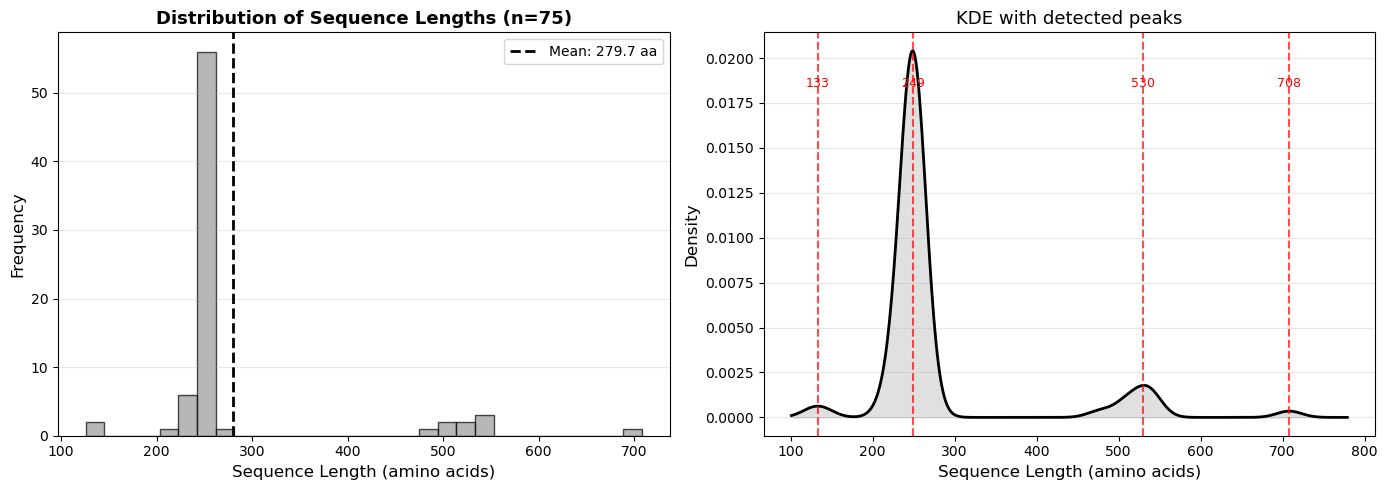


Detected length peaks: ['133', '249', '530', '708']
  ** 249 ~ 2x 133 (ratio 1.87) -> likely monomer/dimer
  ** 530 ~ 2x 249 (ratio 2.13) -> likely monomer/dimer
  ** 708 ~ 3x 249 (ratio 2.85) -> likely monomer/trimer


In [6]:
def load_sequences(fasta_file, outdir):
    """Load sequences from FASTA, display stats, and plot histogram + KDE."""
    COLOR_HIST = "#999999"
    COLOR_MEAN = "#000000"

    sequences = list(SeqIO.parse(fasta_file, "fasta"))
    lengths = np.array([len(s) for s in sequences])
    mean_len = lengths.mean()

    print(f"Loaded {len(sequences)} sequences")
    print("\nSequence length statistics:")
    print(f"  Mean: {mean_len:.1f} aa")
    print(f"  Min:  {lengths.min()} aa")
    print(f"  Max:  {lengths.max()} aa")

    preview("First sequence IDs", [f"{s.id}: {len(s)} aa" for s in sequences[:3]])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: histogram
    axes[0].hist(lengths, bins=30, edgecolor="black", alpha=0.7, color=COLOR_HIST)
    axes[0].axvline(
        mean_len,
        color=COLOR_MEAN,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_len:.1f} aa",
    )
    axes[0].set_xlabel("Sequence Length (amino acids)", fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)
    axes[0].set_title(
        f"Distribution of Sequence Lengths (n={len(sequences)})",
        fontsize=13,
        fontweight="bold",
    )
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    # Right panel: KDE with peak detection
    peak_lengths = []
    if len(lengths) > 5:
        kde = gaussian_kde(lengths, bw_method=0.15)
        x_grid = np.linspace(lengths.min() * 0.8, lengths.max() * 1.1, 500)
        density = kde(x_grid)

        axes[1].plot(x_grid, density, "k-", lw=2)
        axes[1].fill_between(x_grid, density, alpha=0.3, color=COLOR_HIST)

        peaks, _ = find_peaks(density, prominence=0.00005, distance=15)
        peak_lengths = sorted(x_grid[peaks])

        for pl in peak_lengths:
            axes[1].axvline(pl, color="red", ls="--", alpha=0.7)
            axes[1].text(
                pl,
                max(density) * 0.9,
                f"{pl:.0f}",
                ha="center",
                fontsize=9,
                color="red",
            )

        axes[1].set_xlabel("Sequence Length (amino acids)", fontsize=12)
        axes[1].set_ylabel("Density", fontsize=12)
        axes[1].set_title("KDE with detected peaks", fontsize=13)
        axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(outdir / "length_distribution.png", dpi=150)
    plt.show()

    # Report monomer/dimer relationships between peaks
    if peak_lengths:
        print("\nDetected length peaks:", [f"{p:.0f}" for p in peak_lengths])
        for i, p_i in enumerate(peak_lengths):
            for p_j in peak_lengths[i + 1 :]:
                ratio = p_j / p_i
                if 1.7 < ratio < 2.3:
                    print(
                        f"  ** {p_j:.0f} ~ 2x {p_i:.0f} "
                        f"(ratio {ratio:.2f}) -> likely monomer/dimer"
                    )
                elif 2.7 < ratio < 3.3:
                    print(
                        f"  ** {p_j:.0f} ~ 3x {p_i:.0f} "
                        f"(ratio {ratio:.2f}) -> likely monomer/trimer"
                    )

    return sequences, lengths, peak_lengths


sequences, len_arr, peak_lengths = load_sequences(INPUT_FASTA, OUTDIR)
records = sequences

In [7]:
def estimate_monomer_peak(len_arr):
    """
    Find the monomer length peak from the KDE, skipping fragment peaks.

    Returns
    -------
    mono_peak : float
        Estimated monomer length.
    """
    mono_peak = None

    if len(len_arr) > 5:
        kde = gaussian_kde(len_arr, bw_method=0.15)
        x_grid = np.linspace(len_arr.min() * 0.8, len_arr.max() * 1.1, 500)
        density = kde(x_grid)
        peaks, _ = find_peaks(density, prominence=0.00005, distance=15)

        if len(peaks) > 0:
            peak_positions = sorted(x_grid[peaks])
            median_len = np.median(len_arr)

            for p in peak_positions:
                if p < median_len * 0.6:
                    print(
                        f"  Skipping peak at {p:.0f} "
                        f"(likely fragments, < 60% of median {median_len:.0f})"
                    )
                    continue
                mono_peak = p
                break

    if mono_peak is None:
        lower_half = len_arr[len_arr <= np.median(len_arr)]
        mono_peak = np.median(lower_half) if len(lower_half) > 0 else np.median(len_arr)
        print(f"  No clear peak found; using fallback estimate: {mono_peak:.0f}")

    print(f"  Estimated monomer length peak: {mono_peak:.0f}")
    return mono_peak


def get_presumed_monomers(records, len_arr, mono_peak):
    """
    Select sequences within +/-15% of the monomer peak as references.

    Returns
    -------
    candidates : list[SeqRecord]
        Sequences near the monomer peak.
    """
    tolerance = 0.15
    lo = mono_peak * (1 - tolerance)
    hi = mono_peak * (1 + tolerance)
    candidates = [r for r in records if lo <= len(r.seq) <= hi]

    if len(candidates) < 3:
        tolerance = 0.25
        lo = mono_peak * (1 - tolerance)
        hi = mono_peak * (1 + tolerance)
        candidates = [r for r in records if lo <= len(r.seq) <= hi]
        print("  Widened tolerance to +/-25% to get enough candidates")

    if len(candidates) < 3:
        sorted_recs = sorted(records, key=lambda r: abs(len(r.seq) - mono_peak))
        candidates = sorted_recs[: max(5, len(records) // 5)]
        print("  Fallback: selected sequences closest to estimated peak")

    print(f"  Selected {len(candidates)} presumed monomers " f"(length {lo:.0f}-{hi:.0f})")
    return candidates


def count_local_hits(query_seq, ref_seq, min_coverage=0.4):
    """
    Iteratively find non-overlapping local alignments of ref against query.

    After each hit the matched query region is masked with X's and the
    search repeats. Returns a list of hit dicts with coordinates and
    scores.
    """
    from Bio.Align import PairwiseAligner

    aligner = PairwiseAligner()
    aligner.mode = "local"
    aligner.substitution_matrix = BLOSUM62
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5

    query = str(query_seq)
    ref = str(ref_seq)
    ref_len = len(ref)
    min_aln_len = int(ref_len * min_coverage)

    hits = []
    masked = list(query)

    for _ in range(10):
        masked_str = "".join(masked)
        try:
            alignments = aligner.align(masked_str, ref)
            if not alignments:
                break
            aln = alignments[0]
        except (StopIteration, ValueError):
            break

        if aln.score < 15:
            break

        q_start = aln.aligned[0][0][0]
        q_end = aln.aligned[0][-1][1]
        aln_len = q_end - q_start

        if aln_len < min_aln_len:
            break

        norm = aln.score / (ref_len * 5)
        if norm < 0.15:
            break

        hits.append(
            {
                "q_start": q_start,
                "q_end": q_end,
                "score": aln.score,
                "norm_score": norm,
                "aln_len": aln_len,
            }
        )

        for pos in range(q_start, q_end):
            masked[pos] = "X"

    return hits


print("Running profile search...\n")

mono_peak = estimate_monomer_peak(len_arr)
mono_refs = get_presumed_monomers(records, len_arr, mono_peak)

# Primary reference: closest to peak; extras for cross-checking
mono_refs_sorted = sorted(mono_refs, key=lambda r: abs(len(r.seq) - mono_peak))
ref_seq = mono_refs_sorted[0]
extra_refs = mono_refs_sorted[1:4] if len(mono_refs_sorted) > 1 else []

print(f"  Primary reference: {ref_seq.id} (length {len(ref_seq.seq)})")
if extra_refs:
    print(
        f"  Cross-checking with {len(extra_refs)} additional references: "
        f"{[r.id for r in extra_refs]}"
    )
print()

results = []
for i, rec in enumerate(records):
    best_hits = count_local_hits(str(rec.seq), str(ref_seq.seq))

    for eref in extra_refs:
        hits_extra = count_local_hits(str(rec.seq), str(eref.seq))
        if len(hits_extra) > len(best_hits):
            best_hits = hits_extra

    n_hits = len(best_hits)
    classification = UNIT_LABELS.get(n_hits, f"{n_hits}-mer")

    results.append(
        {
            "seq_id": rec.id,
            "length": len(rec.seq),
            "n_hits": n_hits,
            "classification": classification,
            "hits": best_hits,
            "total_score": sum(h["score"] for h in best_hits),
        }
    )

    if (i + 1) % 10 == 0 or i == len(records) - 1:
        print(f"  Scanned {i + 1}/{len(records)}")

Running profile search...

  Skipping peak at 133 (likely fragments, < 60% of median 250)
  Estimated monomer length peak: 249
  Selected 64 presumed monomers (length 212-286)
  Primary reference: P005082012529|Drosophila_mauritiana (length 249)
  Cross-checking with 3 additional references: ['P005103011421|Drosophila_willistoni', 'P005083008910|Drosophila_melanogaster', 'P005093013423|Drosophila_sechellia']

  Scanned 10/75
  Scanned 20/75
  Scanned 30/75
  Scanned 40/75
  Scanned 50/75
  Scanned 60/75
  Scanned 70/75
  Scanned 75/75


Now we can plot the results

                                seq_id  length  n_hits classification  total_score display_label
      P005088004351|Drosophila_obscura     140       1        monomer        333.0       partial
      P005102009207|Drosophila_virilis     126       1        monomer        396.0       partial
       P005073012561|Drosophila_erecta     248       1        monomer       1182.0       monomer
     P005092009946|Drosophila_santomea     250       1        monomer        349.0       monomer
   P005085005288|Drosophila_mojavensis     255       1        monomer        350.5       monomer
    P005076010744|Drosophila_grimshawi     248       1        monomer        316.0       monomer
 P005083008909|Drosophila_melanogaster     250       1        monomer        345.0       monomer
     P005079010340|Drosophila_innubila     246       1        monomer        629.0       monomer
   P005074010565|Drosophila_eugracilis     248       1        monomer       1075.0       monomer
    P005101009090|Drosophila_t

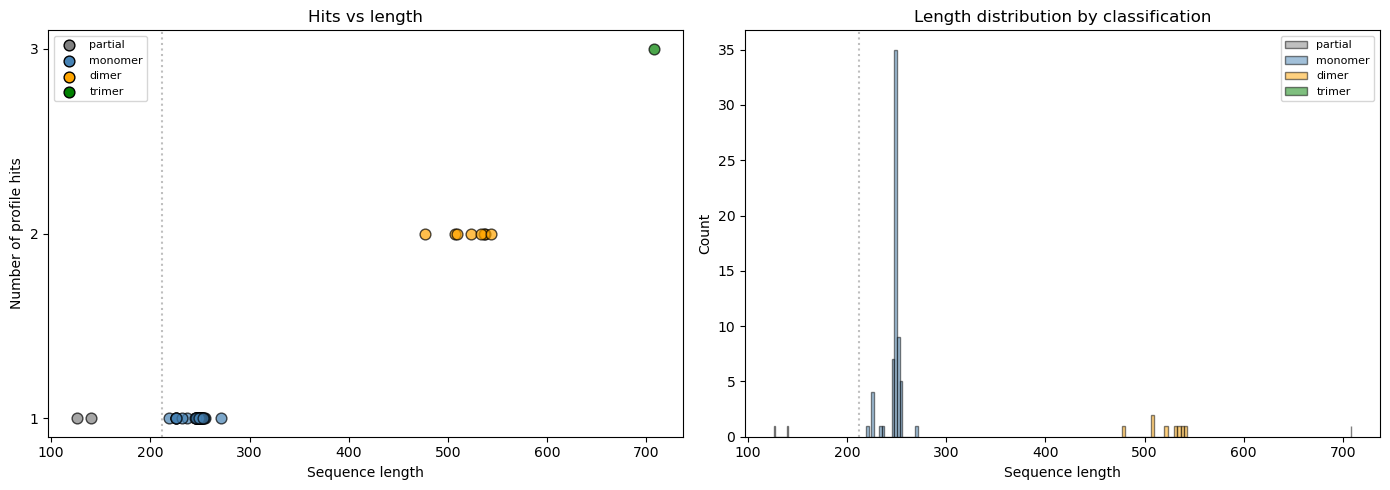

In [8]:
df = pd.DataFrame(
    [
        {
            "seq_id": r["seq_id"],
            "length": r["length"],
            "n_hits": r["n_hits"],
            "classification": r["classification"],
            "total_score": round(r["total_score"], 1),
        }
        for r in results
    ]
)

LABEL_ORDER = ["partial", "monomer", "dimer", "trimer"]


def assign_display_labels(df, mono_peak, tolerance=0.15):
    """Add a display_label column that distinguishes partials."""
    lo = mono_peak * (1 - tolerance)

    labels = []
    for _, row in df.iterrows():
        if row["n_hits"] == 1 and row["length"] < lo:
            labels.append("partial")
        else:
            labels.append(row["classification"])

    df = df.copy()
    df["display_label"] = pd.Categorical(labels, categories=LABEL_ORDER, ordered=True)
    return df, lo


df, lo = assign_display_labels(df, mono_peak)

print(df.sort_values("display_label").to_string(index=False))
print()
print("=== Classification summary ===")
counts = df["display_label"].value_counts().reindex(LABEL_ORDER).dropna()
print(counts.astype(int).to_string())


def plot_summary(df, lo, outdir):
    """Plot classification overview and hit count vs length."""
    color_map = {
        "partial": "grey",
        "monomer": "steelblue",
        "dimer": "orange",
        "trimer": "green",
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for _, row in df.iterrows():
        axes[0].scatter(
            row["length"],
            row["n_hits"],
            s=60,
            alpha=0.7,
            color=color_map.get(row["display_label"], "purple"),
            edgecolors="black",
        )

    axes[0].axvline(lo, color="grey", ls=":", alpha=0.5)
    axes[0].set_xlabel("Sequence length")
    axes[0].set_ylabel("Number of profile hits")
    axes[0].set_title("Hits vs length")
    axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    for lbl in LABEL_ORDER:
        if lbl in df["display_label"].values:
            axes[0].scatter(
                [],
                [],
                color=color_map[lbl],
                edgecolors="black",
                s=60,
                label=lbl,
            )
    axes[0].legend(loc="upper left", fontsize=8)

    for lbl in LABEL_ORDER:
        subset = df[df["display_label"] == lbl]["length"]
        if len(subset) > 0:
            axes[1].hist(
                subset,
                bins=20,
                alpha=0.5,
                edgecolor="black",
                color=color_map[lbl],
                label=lbl,
            )

    axes[1].axvline(lo, color="grey", ls=":", alpha=0.5)
    axes[1].set_xlabel("Sequence length")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Length distribution by classification")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(outdir / "classification_summary.png", dpi=150)
    plt.show()


plot_summary(df, lo, OUTDIR)

And now extract only the monomers to train our profile HMM

In [9]:
def extract_full_length_monomers(records, results, len_arr, tolerance=0.15):
    """
    Extract only full-length monomers, excluding multimers, fragments,
    and anomalously long sequences.

    Parameters
    ----------
    records : list[SeqRecord]
        All input sequences.
    results : list[dict]
        Classification results from profile search.
    len_arr : np.ndarray
        Array of all sequence lengths.
    tolerance : float
        Fractional tolerance around the monomer peak (default 0.15).

    Returns
    -------
    full_length : list[SeqRecord]
        Full-length monomer sequences only.
    mono_peak : float
        Estimated monomer length used for filtering.
    """
    mono_lengths = np.array([r["length"] for r in results if r["n_hits"] == 1])

    if len(mono_lengths) > 5:
        kde = gaussian_kde(mono_lengths, bw_method=0.15)
        x_grid = np.linspace(mono_lengths.min() * 0.8, mono_lengths.max() * 1.1, 500)
        density = kde(x_grid)
        peaks, _ = find_peaks(density, prominence=0.00005, distance=15)

        if len(peaks) > 0:
            peak = x_grid[peaks[np.argmax(density[peaks])]]
        else:
            peak = np.median(mono_lengths)
    else:
        peak = np.median(mono_lengths) if len(mono_lengths) > 0 else np.median(len_arr)

    lo = peak * (1 - tolerance)
    hi = peak * (1 + tolerance)

    print(f"  Monomer length peak: {peak:.0f}")
    print(f"  Accepting lengths: {lo:.0f}-{hi:.0f}")

    monomer_ids = {r["seq_id"] for r in results if r["n_hits"] == 1}

    full_length = []
    n_fragments = 0
    n_too_long = 0

    for rec in records:
        if rec.id not in monomer_ids:
            continue
        seq_len = len(rec.seq)
        if seq_len < lo:
            n_fragments += 1
        elif seq_len > hi:
            n_too_long += 1
        else:
            full_length.append(rec)

    print(f"  Excluded {n_fragments} partial/truncated sequence(s)")
    print(f"  Excluded {n_too_long} anomalously long sequence(s)")

    return full_length, peak


output_units, mono_peak_final = extract_full_length_monomers(records, results, len_arr)
n_multimers = sum(1 for r in results if r["n_hits"] > 1)
n_total_excluded = len(records) - len(output_units)
print(f"  Excluded {n_multimers} multimer sequence(s)")
print(f"  Total excluded: {n_total_excluded}/{len(records)}")
print(f"  Kept {len(output_units)} full-length monomers")

output_fasta = OUTDIR / "monomers_only.fasta"
SeqIO.write(output_units, output_fasta, "fasta")

print(f"\nWrote {len(output_units)} sequences to {output_fasta}")
print()
print("Dimers will show as 2 non-overlapping hits per sequence.")


df.to_csv(OUTDIR / "repeat_classification.csv", index=False)
print(f"Saved to {OUTDIR / 'repeat_classification.csv'}")

  Monomer length peak: 249
  Accepting lengths: 212-287
  Excluded 2 partial/truncated sequence(s)
  Excluded 0 anomalously long sequence(s)
  Excluded 9 multimer sequence(s)
  Total excluded: 11/75
  Kept 64 full-length monomers

Wrote 64 sequences to repeat_detection_results/monomers_only.fasta

Dimers will show as 2 non-overlapping hits per sequence.
Saved to repeat_detection_results/repeat_classification.csv


## Step 3: Multiple Sequence Alignment of Protein Sequences

In this step we will align our 'raw' input sequence data that is present in our input fasta file

In [10]:
def run_mafft(input_file, output_file, method="auto"):
    """
    Run MAFFT multiple sequence alignment.

    Parameters
    ----------
    input_file : str
        Input FASTA file path.
    output_file : str
        Output aligned FASTA file path.
    method : str
        Alignment strategy: 'auto', 'fast' (FFT-NS-2), or 'accurate' (L-INS-i).
    """
    method_flags = {
        "fast": ["--retree", "2", "--maxiterate", "0"],
        "accurate": ["--localpair", "--maxiterate", "1000"],
    }

    cmd = ["mafft"] + method_flags.get(method, []) + [input_file]

    print(f"Running MAFFT alignment (method='{method}')...")
    try:
        with open(output_file, "w") as fh:
            subprocess.run(cmd, stdout=fh, stderr=subprocess.PIPE, text=True, check=True)
        print(f"✓ Alignment complete: {output_file}")
        return True
    except subprocess.CalledProcessError as e:
        print(f"✗ MAFFT failed: {e.stderr}")
        return False

In [11]:
# Run alignment
run_mafft(INPUT_FASTA, ALIGNED_FASTA, method="auto")

Running MAFFT alignment (method='auto')...
✓ Alignment complete: output_files/aligned_proteins.fasta


True

To check that worked we will visualize the alignment.  
Since we know multiple domains are present in some sequences we don't expect this alignment to have worked particlularly well - it will be messy

In [12]:
def visualize_alignment(alignment_file, max_display=50):
    """
    Display conservation and gap frequency across a multiple sequence alignment.

    Parameters
    ----------
    alignment_file : str
        Path to aligned FASTA file.
    max_display : int
        Number of alignment positions to show in the sequence preview.
    """
    COLOR_CONSERVATION = "#000000"  # black
    COLOR_GAPS = "#999999"  # grey

    alignment = AlignIO.read(alignment_file, "fasta")
    n_seqs = len(alignment)
    length = alignment.get_alignment_length()
    print(f"Alignment: {n_seqs} sequences, {length} positions")

    # --- Calculate conservation and gap frequency per column ---
    conservation, gap_frequency = [], []
    for i in range(length):
        col = alignment[:, i]
        counts = Counter(col)
        conservation.append(max(counts.values()) / n_seqs)
        gap_frequency.append(counts.get("-", 0) / n_seqs)

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.set_xlabel("Alignment Position", fontsize=11)
    ax1.set_ylabel("Conservation", color=COLOR_CONSERVATION, fontsize=11)
    ax1.plot(
        conservation,
        linewidth=0.8,
        color=COLOR_CONSERVATION,
        linestyle="-",
        label="Conservation",
        alpha=0.8,
    )
    ax1.tick_params(axis="y", labelcolor=COLOR_CONSERVATION)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Gap Frequency", color=COLOR_GAPS, fontsize=11)
    ax2.plot(
        gap_frequency,
        linewidth=0.8,
        color=COLOR_GAPS,
        linestyle="--",
        label="Gap Frequency",
        alpha=0.7,
    )
    ax2.tick_params(axis="y", labelcolor=COLOR_GAPS)
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

    plt.title("Sequence Conservation and Gap Frequency Across Alignment", fontsize=13, pad=20)
    fig.tight_layout()
    plt.show()

    # --- Summary statistics ---
    avg_con = sum(conservation) / length
    avg_gap = sum(gap_frequency) / length
    max_gap = max(gap_frequency)
    high_gap = sum(1 for g in gap_frequency if g > 0.5)

    print("\nAlignment statistics:")
    print(f"  Average conservation:    {avg_con:.3f}")
    print(f"  Average gap frequency:   {avg_gap:.3f} ({avg_gap * 100:.1f}%)")
    print(f"  Maximum gap frequency:   {max_gap:.3f} ({max_gap * 100:.1f}%)")
    print(f"  Positions with >50% gaps: {high_gap}")

    # --- Sequence preview ---
    print(f"\nAlignment preview (first {min(max_display, length)} positions):")
    for record in alignment[:5]:
        print(f"  {record.id[:20]:20s} {str(record.seq)[:max_display]}")

Alignment: 75 sequences, 1050 positions


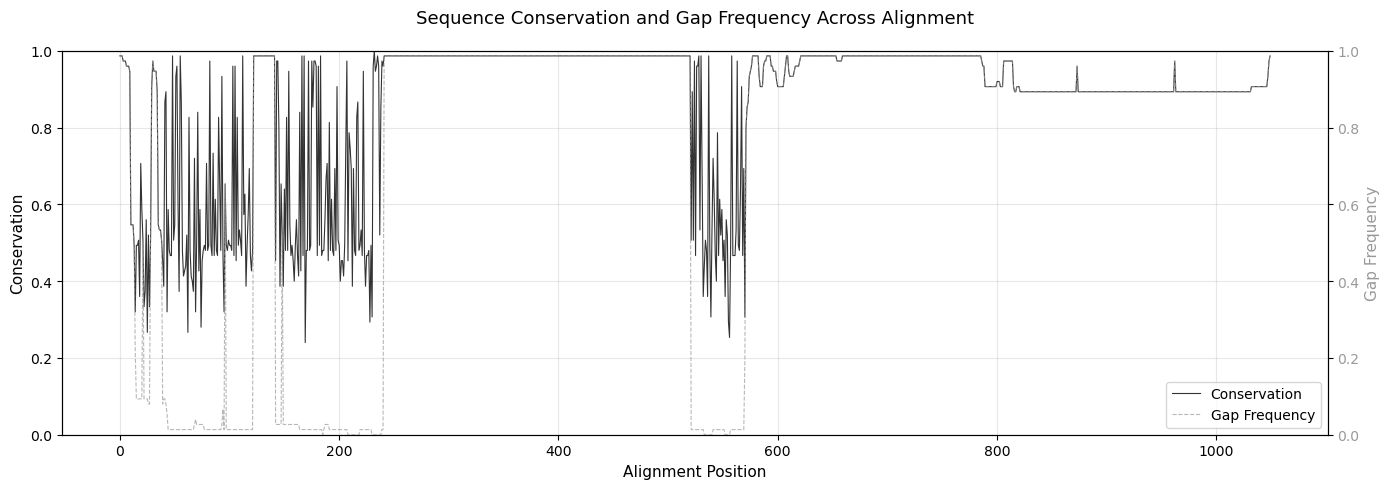


Alignment statistics:
  Average conservation:    0.866
  Average gap frequency:   0.734 (73.4%)
  Maximum gap frequency:   0.987 (98.7%)
  Positions with >50% gaps: 806

Alignment preview (first 50 positions):
  P005101009090|Drosop --------------MMLLQLSCLALFCCL------ASGASNFPPELPRCH
  P005098006594|Drosop -------------MMLLLQLGSVALLFCL------ASGASNFPPELPRCR
  P005102009206|Drosop ----------MSRIIFIVVFC-TVLAVQ-----------AEFPDDPKPCK
  P005086002813|Drosop ---------------MLFAVCSVFLFACL--TLGSASRPSNFPAELPICR
  P005081003743|Drosop --------------MLLLQLSCVALLVCL------ACGASNFPPELPRCK


In [13]:
# Visualize alignment
visualize_alignment(ALIGNED_FASTA)

Now we also want to align and check the monomers only FASTA (which we will use to train our HMM)

Running MAFFT alignment (method='auto')...
✓ Alignment complete: output_files/monomers_only.afa
Alignment: 64 sequences, 292 positions


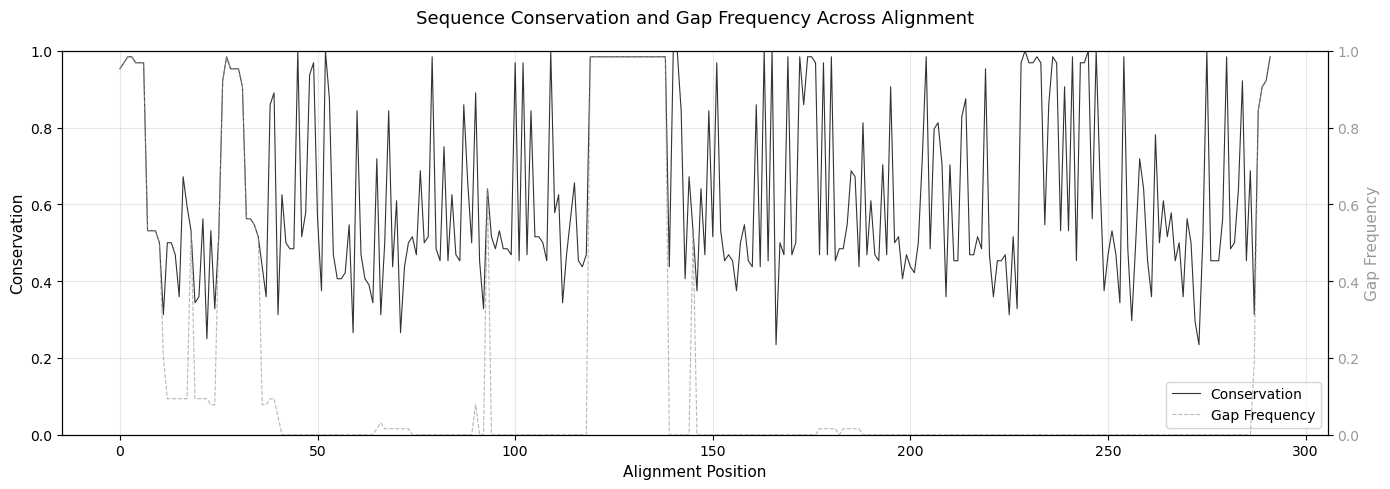


Alignment statistics:
  Average conservation:    0.640
  Average gap frequency:   0.153 (15.3%)
  Maximum gap frequency:   0.984 (98.4%)
  Positions with >50% gaps: 48

Alignment preview (first 50 positions):
  P005101009090|Drosop -----------MMLLQLSCLALFCCL------ASGASNFPPELPRCHTGD
  P005102009206|Drosop -------MSRIIFIVVFC-TVLAVQ-----------AEFPDDPKPCKYGD
  P005086002813|Drosop ------------MLFAVCSVFLFACL--TLGSASRPSNFPAELPICRYGD
  P005082012529|Drosop -------MFAIAFAVVLC-LLVSVE-----------AKFPDDPKPCKYGD
  P005087007761|Drosop -------MSRIIFIVVLC-SVLAVQ-----------AEFPADPKPCKYGD


In [14]:
UNALIGNED_MONOMERS = "repeat_detection_results/monomers_only.fasta"
ALIGNED_MONOMERS = "output_files/monomers_only.afa"
run_mafft(UNALIGNED_MONOMERS, ALIGNED_MONOMERS, method="auto")
visualize_alignment(ALIGNED_MONOMERS)

## Step 4: Build Profile HMM With HMMER

We will now train our HMM on our aligned monomer sequences

In [15]:
def build_hmm(alignment_file, hmm_file, name="MyDomain"):
    """
    Build a profile HMM from a multiple sequence alignment using hmmbuild.

    Parameters
    ----------
    alignment_file : str
        Path to the input aligned FASTA file.
    hmm_file : str
        Path to write the output HMM profile.
    name : str
        Name to assign to the HMM profile.
    """
    cmd = ["hmmbuild", "-n", name, hmm_file, alignment_file]

    print(f"Building HMM profile '{name}'...")
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        print(f"✓ HMM built successfully: {hmm_file}")
        stats = [
            line.strip()
            for line in result.stderr.split("\n")
            if any(k in line for k in ("LENG", "NSEQ", "EFFN"))
        ]
        if stats:
            print("\nHMM statistics:")
            for stat in stats:
                print(f"  {stat}")
        return True
    except subprocess.CalledProcessError as e:
        print(f"✗ hmmbuild failed: {e.stderr}")
        return False

In [16]:
# Build HMM
build_hmm(ALIGNED_MONOMERS, HMM_FILE, name="ProteinDomain")

Building HMM profile 'ProteinDomain'...
✓ HMM built successfully: output_files/protein_domain.hmm


True

## Step 5: Search for Domains Using Profile HMM From Step 3

Since we have our HMM file or profile at this point we can now use it to search for domains across our full input FASTA file

In [17]:
def search_hmm(hmm_file, sequence_file, output_table, evalue=0.001):
    """
    Search sequences against a profile HMM using hmmsearch.

    Parameters
    ----------
    hmm_file : str
        Path to the HMM profile.
    sequence_file : str
        Path to the input FASTA file to search.
    output_table : str
        Path to write the domain hit table output.
    evalue : float
        E-value threshold for reporting hits.
    """
    cmd = [
        "hmmsearch",
        "-E",
        str(evalue),
        "--domE",
        str(evalue),
        "--domtblout",
        output_table,
        hmm_file,
        sequence_file,
    ]

    print(f"Searching for domains (E-value < {evalue})...")
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        print(f"✓ Search complete: {output_table}")
        stats = [
            line.strip()
            for line in result.stdout.split("\n")
            if "queries" in line.lower() or "Scores for" in line
        ]
        if stats:
            for stat in stats:
                print(f"  {stat}")
        return True
    except subprocess.CalledProcessError as e:
        print(f"✗ hmmsearch failed: {e.stderr}")
        return False

In [18]:
# Search for domains
search_hmm(HMM_FILE, INPUT_FASTA, DOMAIN_TABLE, evalue=0.001)

Searching for domains (E-value < 0.001)...
✓ Search complete: output_files/domain_hits.txt
  Scores for complete sequences (score includes all domains):


True

## Step 6: Parse Domain Search Results

Here we are going to parse the output of HMM search to better describe the diversity and location of domains we found

In [19]:
def parse_hmm_domtable(domtable_file):
    """
    Parse a HMMER domain table (--domtblout) into a DataFrame.

    Parameters
    ----------
    domtable_file : str
        Path to the hmmsearch domain table output file.

    Returns
    -------
    pd.DataFrame
        Parsed domain hits with numeric columns cast appropriately.
    """
    columns = [
        "target_name",
        "target_accession",
        "tlen",
        "query_name",
        "query_accession",
        "qlen",
        "full_evalue",
        "full_score",
        "full_bias",
        "domain_num",
        "domain_total",
        "domain_cevalue",
        "domain_ievalue",
        "domain_score",
        "domain_bias",
        "hmm_from",
        "hmm_to",
        "ali_from",
        "ali_to",
        "env_from",
        "env_to",
        "acc",
        "description",
    ]

    numeric_cols = {
        "tlen",
        "qlen",
        "full_evalue",
        "full_score",
        "full_bias",
        "domain_num",
        "domain_total",
        "domain_cevalue",
        "domain_ievalue",
        "domain_score",
        "domain_bias",
        "hmm_from",
        "hmm_to",
        "ali_from",
        "ali_to",
        "env_from",
        "env_to",
        "acc",
    }

    with open(domtable_file) as fh:
        data = [line.split(None, 22) for line in fh if not line.startswith("#")]

    df = pd.DataFrame(data, columns=columns)
    df[list(numeric_cols)] = df[list(numeric_cols)].apply(pd.to_numeric)

    return df

In [20]:
def summarize_domain_hits(df):
    """
    Display summary statistics and distributions for HMMER domain hits.

    Parameters
    ----------
    df : pd.DataFrame
        Parsed domain hit table from parse_hmm_domtable().

    Returns
    -------
    pd.DataFrame
        Input DataFrame with an added 'domain_length' column.
    """
    COLOR_HIST = "#999999"  # grey

    df["domain_length"] = df["env_to"] - df["env_from"] + 1

    print("Domain Search Summary")
    print("=" * 50)
    print(f"  Total domain hits:            {len(df)}")
    print(f"  Unique proteins with hits:    {df['target_name'].nunique()}")

    for label, col in [("E-value", "domain_ievalue"), ("Domain length", "domain_length")]:
        unit = "" if label == "E-value" else " aa"
        fmt = ".2e" if label == "E-value" else ".1f"
        print(f"\n{label} statistics:")
        for stat, val in [
            ("Mean", df[col].mean()),
            ("Median", df[col].median()),
            ("Min", df[col].min()),
            ("Max", df[col].max()),
        ]:
            print(f"  {stat+':':8s} {val:{fmt}}{unit}")

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(-np.log10(df["domain_ievalue"]), bins=30, color=COLOR_HIST, edgecolor="black")
    axes[0].set_xlabel("-log10(E-value)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("E-value Distribution")
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(df["domain_length"], bins=30, color=COLOR_HIST, edgecolor="black")
    axes[1].set_xlabel("Domain Length (aa)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Domain Length Distribution")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df

Domain Search Summary
  Total domain hits:            85
  Unique proteins with hits:    75

E-value statistics:
  Mean:    2.12e-44
  Median:  1.30e-109
  Min:     4.00e-121
  Max:     1.80e-42

Domain length statistics:
  Mean:    243.5 aa
  Median:  248.0 aa
  Min:     111.0 aa
  Max:     268.0 aa


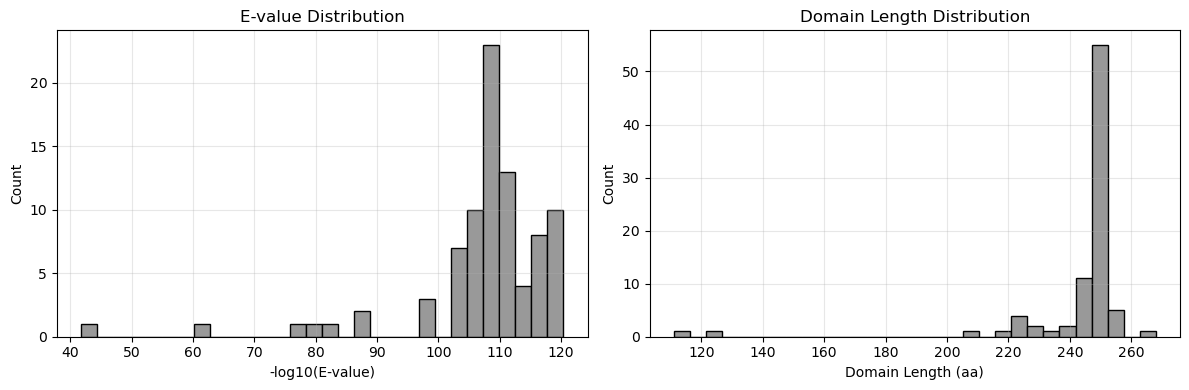

,target_name,target_accession,tlen,query_name,query_accession,qlen,full_evalue,full_score,full_bias,domain_num,...,domain_bias,hmm_from,hmm_to,ali_from,ali_to,env_from,env_to,acc,description,domain_length
0,P005081003743|Drosophila_kikkawai,-,708,ProteinDomain,-,247,2.000000e-304,995.7,0.2,1,...,0.0,7,247,4,250,1,250,0.96,-\n,250
1,P005081003743|Drosophila_kikkawai,-,708,ProteinDomain,-,247,2.000000e-304,995.7,0.2,2,...,0.0,22,224,252,454,251,459,0.99,-\n,209
2,P005081003743|Drosophila_kikkawai,-,708,ProteinDomain,-,247,2.000000e-304,995.7,0.2,3,...,0.1,3,247,462,706,460,706,0.99,-\n,247
3,P005098006594|Drosophila_subpulchrella,-,537,ProteinDomain,-,247,2.300000e-225,736.8,0.4,1,...,0.0,7,247,4,251,1,251,0.96,-\n,251
4,P005098006594|Drosophila_subpulchrella,-,537,ProteinDomain,-,247,2.300000e-225,736.8,0.4,2,...,0.3,1,247,290,537,290,537,0.99,-\n,248


In [21]:
# Parse and summarize results
domain_df = parse_hmm_domtable(DOMAIN_TABLE)
domain_df = summarize_domain_hits(domain_df)
domain_df.head()

## Step 7: Extract Domain-Specific Alignments From Original FASTA File

Now we'll search the original sequences again with our HMM and extract domain regions as separate sequences.  
If a protein has multiple domains, they'll be split into separate entries (part1, part2, etc.).

In [22]:
def extract_domain_alignments(sequence_file, domain_df, output_file, evalue_cutoff=None):
    """
    Extract domain sequences with proper naming for multi-domain proteins.

    Proteins with multiple domains get _part1, _part2, etc. suffixes.
    Filters out sequences shorter than mean - 2 standard deviations.

    Parameters
    ----------
    sequence_file : str
        Path to the original FASTA file.
    domain_df : pd.DataFrame
        Domain hit table from parse_hmm_domtable().
    output_file : str
        Path to write extracted domain sequences.
    evalue_cutoff : float, optional
        E-value threshold for filtering hits.

    Returns
    -------
    tuple
        (domain_counts dict, list of filtered SeqRecord objects)
    """
    COLOR_BAR_ORIGINAL = "#999999"  # grey
    COLOR_BAR_FILTERED = "#000000"  # black

    def _parse_num_domains(seq_id):
        """Extract total domain count from a sequence ID like 'P123|part1_of2'."""
        try:
            return int(seq_id.split("_of")[1].split()[0])
        except (IndexError, ValueError):
            return 1

    def _bar_labels(ax, bars):
        """Add integer count labels above each bar."""
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h,
                str(int(h)),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )

    # --- Apply E-value filter ---
    if evalue_cutoff:
        domain_df = domain_df[domain_df["domain_ievalue"] <= evalue_cutoff]
        print(f"Applying E-value cutoff {evalue_cutoff}: {len(domain_df)} domains retained")

    sequences = SeqIO.to_dict(SeqIO.parse(sequence_file, "fasta"))

    # --- Extract domain sequences ---
    domain_counts = {}
    extracted_all = []

    for protein_id, domains in domain_df.groupby("target_name"):
        if protein_id not in sequences:
            print(f"  Warning: {protein_id} not found in sequence file")
            continue

        seq = sequences[protein_id]
        domains_sorted = domains.sort_values("env_from")
        n = len(domains_sorted)
        domain_counts[protein_id] = n

        for part, (_, row) in enumerate(domains_sorted.iterrows(), start=1):
            start, end = int(row["env_from"]) - 1, int(row["env_to"])
            domain_seq = seq[start:end]
            domain_seq.id = f"{protein_id}|part{part}_of{n}"
            domain_seq.description = (
                f"{'single_domain' if n == 1 else f'part{part}of{n}'} "
                f"pos:{int(row['env_from'])}-{int(row['env_to'])} "
                f"E-value:{row['domain_ievalue']:.2e} "
                f"score:{row['domain_score']:.1f}"
            )
            extracted_all.append(domain_seq)

    # --- Length filtering (mean - 2*SD) ---
    lengths = np.array([len(s) for s in extracted_all])
    mean_len, std_len = np.mean(lengths), np.std(lengths)
    cutoff = mean_len - 2 * std_len

    print("\nLength filtering:")
    print(f"  Mean:               {mean_len:.1f} aa")
    print(f"  Std dev:            {std_len:.1f} aa")
    print(f"  Cutoff (mean-2*SD): {cutoff:.1f} aa")

    extracted_filtered = [s for s in extracted_all if len(s) >= cutoff]
    removed = [s for s in extracted_all if len(s) < cutoff]

    print(f"  Retained: {len(extracted_filtered)}")
    print(f"  Removed:  {len(removed)}")

    if removed:
        removed_by_n = Counter(_parse_num_domains(s.id) for s in removed)
        print("\n  Removed sequences by domain count:")
        for n in sorted(removed_by_n):
            print(f"    {removed_by_n[n]} sequence(s) from {n}-domain protein(s)")

    # --- Write outputs ---
    SeqIO.write(extracted_filtered, output_file, "fasta")

    removed_file = "output_files/removed_partial_domains.txt"
    with open(removed_file, "w") as fh:
        fh.write(
            f"# Sequences removed for being < mean - 2*SD in length\n"
            f"# Length cutoff: {cutoff:.1f} aa\n"
            f"# Total removed: {len(removed)}\n#\n"
        )
        for s in removed:
            fh.write(f">{s.id} length={len(s)} {s.description}\n")

    print(f"\n✓ Extracted {len(extracted_filtered)} domain sequences to: {output_file}")
    print(f"✓ Removed sequence headers saved to: {removed_file}")

    # --- Summary stats ---
    count_dist = Counter(domain_counts.values())
    print("\nDomain distribution:")
    for n in sorted(count_dist):
        print(f"  {count_dist[n]} protein(s) with {n} domain(s)")

    filt_lengths = [len(s) for s in extracted_filtered]
    print("\nFiltered domain statistics:")
    print(f"  Total:  {len(filt_lengths)}")
    print(f"  Mean:   {np.mean(filt_lengths):.1f} aa")
    print(f"  Min:    {min(filt_lengths)} aa")
    print(f"  Max:    {max(filt_lengths)} aa")

    # --- Plots ---
    def _domain_dist(seqs):
        """Count proteins per domain number from filtered sequence IDs."""
        counts = Counter()
        for s in seqs:
            if "|part" in s.id and "_of" in s.id:
                n = _parse_num_domains(s.id)
                if f"part1_of{n}" in s.id:
                    counts[n] += 1
        return counts or Counter({1: len(seqs)})

    orig_dist = count_dist
    filt_dist = _domain_dist(extracted_filtered)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    for ax, dist, color, title in [
        (
            ax1,
            orig_dist,
            COLOR_BAR_ORIGINAL,
            f"Original Domain Distribution\n({len(domain_counts)} Proteins)",
        ),
        (
            ax2,
            filt_dist,
            COLOR_BAR_FILTERED,
            f"Domain Distribution After Filtering\n({sum(filt_dist.values())} Proteins)",
        ),
    ]:
        ns = sorted(dist.keys())
        bars = ax.bar(ns, [dist[n] for n in ns], color=color, edgecolor="black", alpha=0.7)
        _bar_labels(ax, bars)
        ax.set_xlabel("Number of Domains per Protein", fontsize=12, fontweight="bold")
        ax.set_ylabel("Number of Proteins", fontsize=12, fontweight="bold")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xticks(ns)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    return domain_counts, extracted_filtered

Applying E-value cutoff 0.001: 85 domains retained

Length filtering:
  Mean:               243.5 aa
  Std dev:            21.2 aa
  Cutoff (mean-2*SD): 201.1 aa
  Retained: 83
  Removed:  2

  Removed sequences by domain count:
    2 sequence(s) from 1-domain protein(s)

✓ Extracted 83 domain sequences to: output_files/domain_sequences.fasta
✓ Removed sequence headers saved to: output_files/removed_partial_domains.txt

Domain distribution:
  66 protein(s) with 1 domain(s)
  8 protein(s) with 2 domain(s)
  1 protein(s) with 3 domain(s)

Filtered domain statistics:
  Total:  83
  Mean:   246.5 aa
  Min:    209 aa
  Max:    268 aa


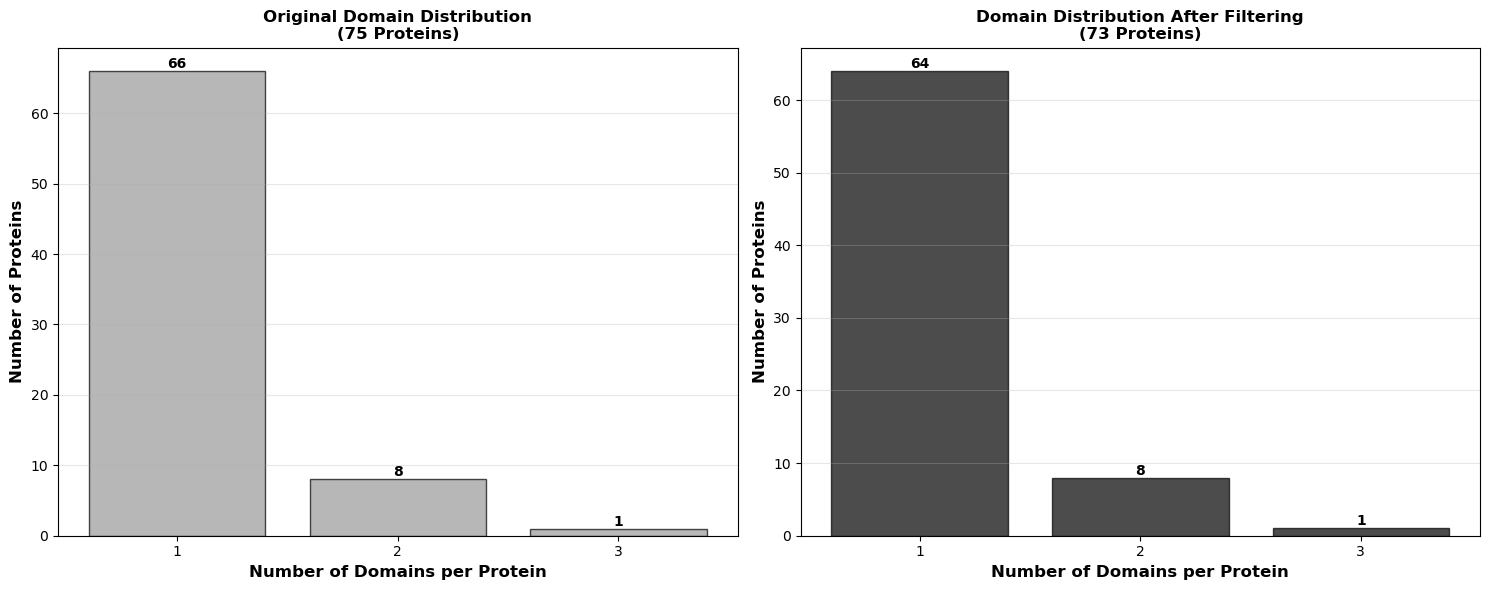

In [24]:
# Extract domain alignments with proper naming
domain_counts, domain_sequences = extract_domain_alignments(
    INPUT_FASTA, domain_df, DOMAIN_SEQUENCES, evalue_cutoff=0.001
)

Now we just want a list showing how many domains were present for each species in total.  
This will include those from single copy domains and the core domains of a split tandem-dimer for example).  
N.B. Since we added REF to our reference sequences these will show up as separate to the other sequences from those species.  

In [25]:
# --- Parse species names from domain FASTA headers ---
print(f"Reading {DOMAIN_SEQUENCES}...")

species_list = []
for record in SeqIO.parse(DOMAIN_SEQUENCES, "fasta"):
    parts = record.id.split("|")
    if len(parts) >= 2:
        species_list.append(parts[1])
    else:
        print(f"  Warning: could not parse species from header: {record.id}")

species_counts = Counter(species_list)

# Strip trailing "REF" suffix for unique species count
unique_species = {s[:-3] if s.endswith("REF") else s for s in species_counts}
ref_sequences = sum(c for s, c in species_counts.items() if s.endswith("REF"))

# --- Print summary ---
print(f"\n{'='*60}\nSPECIES SUMMARY\n{'='*60}")
print(f"  Total sequences:                  {len(species_list)}")
print(f"  Unique species (excl. REF suffix): {len(unique_species)}")
if ref_sequences:
    print(f"  Sequences with REF suffix:        {ref_sequences}")

print(f"\n{'='*60}\nSequences per species:\n{'='*60}")
for species, count in sorted(species_counts.items(), key=lambda x: (-x[1], x[0])):
    print(f"  {species}: {count}")

# --- Build and display summary DataFrame ---
species_df = (
    pd.DataFrame(species_counts.items(), columns=["Species", "Count"])
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

print(f"\n{'='*60}\nSummary DataFrame:\n{'='*60}")
display(species_df)

species_df.to_csv("output_files/species_counts.csv", index=False)
print("\n✓ Saved species counts to: species_counts.csv")

Reading output_files/domain_sequences.fasta...

SPECIES SUMMARY
  Total sequences:                  83
  Unique species (excl. REF suffix): 36
  Sequences with REF suffix:        2

Sequences per species:
  Drosophila_kikkawai: 4
  Drosophila_albomicans: 3
  Drosophila_ananassae: 3
  Drosophila_grimshawi: 3
  Drosophila_guanche: 3
  Drosophila_innubila: 3
  Drosophila_ironensis: 3
  Drosophila_novamexicana: 3
  Drosophila_obscura: 3
  Drosophila_setifemur: 3
  Drosophila_subobscura: 3
  Drosophila_arizonae: 2
  Drosophila_biarmipes: 2
  Drosophila_bipectinata: 2
  Drosophila_bunnanda: 2
  Drosophila_busckii: 2
  Drosophila_elegans: 2
  Drosophila_eugracilis: 2
  Drosophila_hydei: 2
  Drosophila_mauritiana: 2
  Drosophila_melanogaster: 2
  Drosophila_miranda: 2
  Drosophila_mojavensis: 2
  Drosophila_navojoa: 2
  Drosophila_persimilis: 2
  Drosophila_santomea: 2
  Drosophila_sechellia: 2
  Drosophila_subpulchrella: 2
  Drosophila_suzukii: 2
  Drosophila_takahashii: 2
  Drosophila_teissi

,Species,Count
0,Drosophila_kikkawai,4
1,Drosophila_ironensis,3
2,Drosophila_guanche,3
3,Drosophila_ananassae,3
4,Drosophila_subobscura,3
5,Drosophila_setifemur,3
6,Drosophila_innubila,3
7,Drosophila_albomicans,3
8,Drosophila_obscura,3
9,Drosophila_novamexicana,3



✓ Saved species counts to: species_counts.csv


### View Example Domain Sequences

In [26]:
# Display first few extracted domain sequences
print("First 5 extracted domain sequences:\n")
for i, seq in enumerate(domain_sequences[:2]):
    print(f"{i+1}. {seq.id}")
    print(f"   Description: {seq.description}")
    print(f"   Length: {len(seq)} aa")
    print(f"   Sequence: {str(seq.seq)[:60]}...\n")

First 5 extracted domain sequences:

1. B4KE22|Drosophila_mojavensisREF|part1_of1
   Description: single_domain pos:1-251 E-value:1.00e-79 score:259.7
   Length: 251 aa
   Sequence: MHTFSLLLVILLMLYKTSLGIELPDDIKKCHFGDSQCLIHTMNELIRRYPNGIPGIGLAP...

2. P005064008787|Drosophila_albomicans|part1_of2
   Description: part1of2 pos:11-257 E-value:1.00e-116 score:380.9
   Length: 247 aa
   Sequence: MSRLICFLVLCTIVAVQAKFPDDPKPCKHGDTECILNIINYFIAEESTAGVREINLVKLD...



## Step 8: Split PDB Files by Domain Boundaries

Since we downloaded PDB structure files that corresponded with our input sequences we now need to separate them too now we know we have subdomains we want to compare like for like. The output should mean that for each domain in our fasta file we now have a corresponding structure (allowing us to compare across strucures with TM-align). These output files are being named the same way as our new cut sequences.

In [27]:
class DomainSelect(Select):
    """Select residues within a domain range for PDB extraction."""

    def __init__(self, chain_id, start_res, end_res):
        self.chain_id = chain_id
        self.start_res = start_res
        self.end_res = end_res

    def accept_residue(self, residue):
        return int(self.start_res <= residue.get_id()[1] <= self.end_res)

    def accept_chain(self, chain):
        return 1 if self.chain_id is None else int(chain.get_id() == self.chain_id)


def extract_protein_id_from_pdb(pdb_filename):
    """
    Extract protein ID from a PDB filename.

    Examples
    --------
    'P005064013138.pdb' -> 'P005064013138'
    'protein_ABC.pdb'   -> 'protein_ABC'
    """
    return os.path.splitext(pdb_filename)[0]


def extract_species_from_protein_id(protein_id):
    """
    Extract species name from a pipe-delimited protein ID.

    Example
    -------
    'P005064008787|Drosophila_albomicans|one' -> 'Drosophila_albomicans'
    """
    parts = protein_id.split("|")
    return parts[1] if len(parts) >= 2 else None


def find_matching_protein_id(pdb_id, domain_df):
    """
    Find a matching protein ID in domain_df for a given PDB ID.

    Tries exact match first, then substring matches in both directions.

    Parameters
    ----------
    pdb_id : str
        Protein ID derived from the PDB filename.
    domain_df : pd.DataFrame
        Domain hit table from parse_hmm_domtable().

    Returns
    -------
    str or None
        Matching target_name, or None if no match found.
    """
    targets = domain_df["target_name"]

    if pdb_id in targets.values:
        return pdb_id

    matches = domain_df[targets.str.contains(pdb_id, regex=False)]
    if not matches.empty:
        return matches.iloc[0]["target_name"]

    for target in targets.unique():
        if target in pdb_id:
            return target

    return None


def split_pdb_by_domains(pdb_file, domain_df, protein_id, output_dir="pdb_domains", chain_id=None):
    """
    Split a PDB file into separate domain PDB files.

    Parameters
    ----------
    pdb_file : str
        Path to the input PDB file.
    domain_df : pd.DataFrame
        Domain hit table from parse_hmm_domtable().
    protein_id : str
        Protein ID matching a target_name in domain_df.
    output_dir : str
        Directory to write domain PDB files.
    chain_id : str or None
        Specific chain to extract; None extracts all chains.

    Returns
    -------
    list of str
        Paths to the written domain PDB files.
    """
    os.makedirs(output_dir, exist_ok=True)

    protein_domains = domain_df[domain_df["target_name"] == protein_id].sort_values("env_from")
    if protein_domains.empty:
        print(f"  ⚠️  No domains found for {protein_id}")
        return []

    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure(protein_id, pdb_file)
    except Exception as e:
        print(f"  ✗ Error parsing {pdb_file}: {e}")
        return []

    pdb_base = os.path.splitext(os.path.basename(pdb_file))[0]
    species = extract_species_from_protein_id(protein_id)
    n = len(protein_domains)
    species_tag = f"_{species}" if species else ""

    print(f"  Splitting {pdb_base} into {n} domain(s)...")
    if species:
        print(f"  Species: {species}")

    io = PDBIO()
    io.set_structure(structure)
    output_files = []

    for part, (_, domain) in enumerate(protein_domains.iterrows(), start=1):
        start_res, end_res = int(domain["env_from"]), int(domain["env_to"])
        out = os.path.join(output_dir, f"{pdb_base}{species_tag}_part{part}_of{n}.pdb")
        io.save(out, DomainSelect(chain_id, start_res, end_res))
        output_files.append(out)
        print(f"    Part {part}: residues {start_res}-{end_res} → {os.path.basename(out)}")

    return output_files


def batch_split_pdbs(
    pdb_dir, domain_df, output_dir="pdb_domains", chain_id=None, pdb_extension=".pdb"
):
    """
    Batch process all PDB files in a directory.

    Parameters
    ----------
    pdb_dir : str
        Directory containing PDB files.
    domain_df : pd.DataFrame
        Domain hit table from parse_hmm_domtable().
    output_dir : str
        Directory to write domain PDB files.
    chain_id : str or None
        Specific chain to extract; None extracts all chains.
    pdb_extension : str
        File extension to filter PDB files.

    Returns
    -------
    dict
        Mapping of protein IDs to lists of output PDB file paths.
    """
    if not os.path.exists(pdb_dir):
        print(f"✗ PDB directory not found: {pdb_dir}")
        return {}

    pdb_files = sorted(f for f in os.listdir(pdb_dir) if f.endswith(pdb_extension))

    print(f"\n{'='*60}\nProcessing PDB Files\n{'='*60}")
    print(f"  PDB directory:    {pdb_dir}")
    print(f"  Found:            {len(pdb_files)} PDB file(s)")
    print(f"  Output directory: {output_dir}\n")

    all_outputs, not_found = {}, []

    for pdb_file in pdb_files:
        pdb_id = extract_protein_id_from_pdb(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        print(f"Processing: {pdb_file}")

        protein_id = find_matching_protein_id(pdb_id, domain_df)
        if protein_id is None:
            print(f"  ⚠️  No matching protein found in domain data for {pdb_id}")
            not_found.append(pdb_file)
            print()
            continue

        if protein_id != pdb_id:
            print(f"  Matched to: {protein_id}")

        try:
            output_files = split_pdb_by_domains(
                pdb_path, domain_df, protein_id, output_dir=output_dir, chain_id=chain_id
            )
            if output_files:
                all_outputs[pdb_id] = output_files
        except Exception as e:
            print(f"  ✗ Error processing {pdb_file}: {e}")
        print()

    total_domains = sum(len(f) for f in all_outputs.values())
    print(f"{'='*60}\nSummary\n{'='*60}")
    print(f"  ✓ Successfully processed: {len(all_outputs)} structure(s)")
    print(f"  ✓ Total domain PDBs created: {total_domains}")

    if not_found:
        print(f"\n  ⚠️  PDB files without domain matches ({len(not_found)}):")
        for pdb in not_found:
            print(f"    - {pdb}")

    return all_outputs

### Batch Process All PDB Files

In [28]:
# Process all PDB files in the directory specified in the configuration
pdb_outputs = batch_split_pdbs(
    pdb_dir=PDB_DIR,
    domain_df=domain_df,
    output_dir="pdb_domains",
    chain_id=None,  # None = all chains, or specify like "A" for chain A only
)


Processing PDB Files
  PDB directory:    ./tips_data/Structure
  Found:            75 PDB file(s)
  Output directory: pdb_domains

Processing: B4KE22.pdb
  Matched to: B4KE22|Drosophila_mojavensisREF
  Splitting B4KE22 into 1 domain(s)...
  Species: Drosophila_mojavensisREF
    Part 1: residues 1-251 → B4KE22_Drosophila_mojavensisREF_part1_of1.pdb

Processing: P005064008787.pdb
  Matched to: P005064008787|Drosophila_albomicans
  Splitting P005064008787 into 2 domain(s)...
  Species: Drosophila_albomicans
    Part 1: residues 11-257 → P005064008787_Drosophila_albomicans_part1_of2.pdb
    Part 2: residues 291-536 → P005064008787_Drosophila_albomicans_part2_of2.pdb

Processing: P005064013138.pdb
  Matched to: P005064013138|Drosophila_albomicans
  Splitting P005064013138 into 1 domain(s)...
  Species: Drosophila_albomicans
    Part 1: residues 1-251 → P005064013138_Drosophila_albomicans_part1_of1.pdb

Processing: P005065001328.pdb
  Matched to: P005065001328|Drosophila_ananassae
  Splitti

### Verify Domain PDB Files

In [29]:
def verify_domain_pdbs(output_dir="pdb_domains"):
    """
    Verify and summarize extracted domain PDB files.

    Parameters
    ----------
    output_dir : str
        Directory containing domain PDB files.
    """
    parser = PDBParser(QUIET=True)
    pdb_files = sorted(f for f in os.listdir(output_dir) if f.endswith(".pdb"))

    print(f"Domain PDB Files Summary\n{'='*60}")
    print(f"  Total files: {len(pdb_files)}\n")

    for pdb_file in pdb_files:
        pdb_path = os.path.join(output_dir, pdb_file)
        try:
            structure = parser.get_structure("domain", pdb_path)
            residues = list(structure.get_residues())
            res_ids = [r.get_id()[1] for r in residues]
            atoms = list(structure.get_atoms())
            print(f"  {pdb_file}:")
            print(f"    Residues: {len(residues)} (range: {min(res_ids)}-{max(res_ids)})")
            print(f"    Atoms:    {len(atoms)}\n")
        except Exception as e:
            print(f"  {pdb_file}: Error - {e}\n")


verify_domain_pdbs("pdb_domains")

Domain PDB Files Summary
  Total files: 85

  B4KE22_Drosophila_mojavensisREF_part1_of1.pdb:
    Residues: 251 (range: 1-251)
    Atoms:    2062

  P005064008787_Drosophila_albomicans_part1_of2.pdb:
    Residues: 247 (range: 11-257)
    Atoms:    1938

  P005064008787_Drosophila_albomicans_part2_of2.pdb:
    Residues: 246 (range: 291-536)
    Atoms:    1953

  P005064013138_Drosophila_albomicans_part1_of1.pdb:
    Residues: 251 (range: 1-251)
    Atoms:    1966

  P005065001328_Drosophila_ananassae_part1_of2.pdb:
    Residues: 248 (range: 1-248)
    Atoms:    1913

  P005065001328_Drosophila_ananassae_part2_of2.pdb:
    Residues: 254 (range: 279-532)
    Atoms:    1958

  P005065003751_Drosophila_ananassae_part1_of1.pdb:
    Residues: 250 (range: 1-250)
    Atoms:    1966

  P005066011807_Drosophila_arizonae_part1_of2.pdb:
    Residues: 255 (range: 1-255)
    Atoms:    2009

  P005066011807_Drosophila_arizonae_part2_of2.pdb:
    Residues: 231 (range: 277-507)
    Atoms:    1796

  P005

At this point naming is as follows:  
- Input Header - >P005064008787|Drosophila_albomicans
- Domain Fasta Header - >P005064008787|Drosophila_albomicans|part1_of2 part1of2 pos:7-289 E-value:5.00e-148 score:486.8
- Domain Split Proteins - P005064008787_Drosophila_albomicans_part1_of2

## Step 9: Align Domain Sequences

Now we'll align the extracted domain sequences to prepare for phylogenetic analysis and calculate sequence-based distances and once again make a plot of the alginment - this time it looks way better.

In [30]:
def align_domain_sequences(domain_fasta, output_aligned, method="auto"):
    """
    Align extracted domain sequences using MAFFT.

    Wrapper around run_mafft() with alignment summary statistics.

    Parameters
    ----------
    domain_fasta : str
        Path to the input domain FASTA file.
    output_aligned : str
        Path to write the aligned output FASTA.
    method : str
        Alignment strategy: 'auto', 'fast' (FFT-NS-2), or 'accurate' (L-INS-i).

    Returns
    -------
    bool
        True if alignment succeeded, False otherwise.
    """
    success = run_mafft(domain_fasta, output_aligned, method=method)

    if success:
        alignment = AlignIO.read(output_aligned, "fasta")
        print(f"  Sequences:        {len(alignment)}")
        print(f"  Alignment length: {alignment.get_alignment_length()}")

    return success

Running MAFFT alignment (method='auto')...
✓ Alignment complete: output_files/domain_sequences_aligned.fasta
  Sequences:        83
  Alignment length: 283
Alignment: 83 sequences, 283 positions


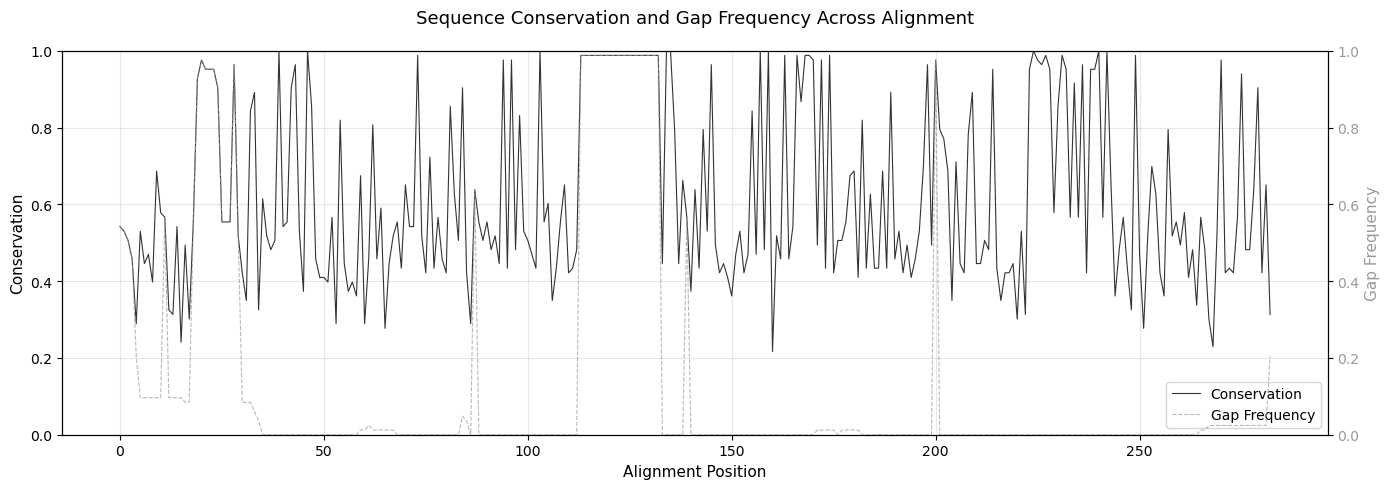


Alignment statistics:
  Average conservation:    0.624
  Average gap frequency:   0.129 (12.9%)
  Maximum gap frequency:   0.988 (98.8%)
  Positions with >50% gaps: 39

Alignment preview (first 50 positions):
  B4KE22|Drosophila_mo MHTFSLLLVILLMLYKTSL----------GIELPDDIKKCHFGDSQCLIH
  P005064008787|Drosop MSRLICFLVLC-TIVAVQ------------AKFPDDPKPCKHGDTECILN
  P005064008787|Drosop MSRLIFIIVSC-IFVTVQ------------GDFPDDPKPCKHSNSECIKN
  P005064013138|Drosop -----MLLQLCSVVLLGLAL----GANG-ASNFPAELPRCHYSDTQCIIN
  P005065001328|Drosop MTGVILAIVLC-LSVAVK------------AEFPDDPKPCKYGDGDCIVK


In [31]:
# Align domain sequences
DOMAIN_ALIGNED = "output_files/domain_sequences_aligned.fasta"
align_domain_sequences(DOMAIN_SEQUENCES, DOMAIN_ALIGNED, method="auto")

# Visualize domain alignment
visualize_alignment(DOMAIN_ALIGNED)

We can see here that the maximum aligned sequence length has decreased indicating we successfully cut up a protein with two domains. We also reduced gaps across the alignment in general with only a small gap spanned by a single sequence reamaining.

## Step 10: Infer Phylogenetic Tree From Our Newly Aligned Domains

To compare structural similarity/variation across evolutionary distances and sequence differences we need a phylogenetic tree for our protein group. Currently this works best with fasttree but to use IQtree (particularly for smaller trees) swap out the `method`

In [32]:
def build_phylogenetic_tree(aligned_fasta, output_tree, method="fasttree"):
    """
    Build a phylogenetic tree from aligned sequences.

    Parameters
    ----------
    aligned_fasta : str
        Path to the aligned FASTA file.
    output_tree : str
        Path to write the output Newick tree file.
    method : str
        Tree inference method: 'fasttree' or 'iqtree'.

    Returns
    -------
    bool
        True if tree was built successfully, False otherwise.
    """
    print(f"Building phylogenetic tree (method='{method}')...")

    try:
        if method == "fasttree":
            with open(output_tree, "w") as fh:
                subprocess.run(
                    ["FastTree", aligned_fasta],
                    stdout=fh,
                    stderr=subprocess.PIPE,
                    text=True,
                    check=True,
                )

        elif method == "iqtree":
            subprocess.run(
                ["iqtree", "-s", aligned_fasta, "-m", "MFP", "-nt", "AUTO"],
                capture_output=True,
                text=True,
                check=True,
            )
            iqtree_output = aligned_fasta + ".treefile"
            if os.path.exists(iqtree_output):
                shutil.move(iqtree_output, output_tree)

        else:
            print(f"✗ Unknown method: {method}")
            return False

    except subprocess.CalledProcessError as e:
        print(f"✗ {method} failed: {e.stderr}")
        return False

    print(f"✓ Tree built successfully: {output_tree}")
    midpoint_root_tree(output_tree)
    return True


def midpoint_root_tree(tree_file):
    """
    Create a midpoint-rooted copy of a Newick tree.

    Parameters
    ----------
    tree_file : str
        Path to the input Newick tree file.

    Returns
    -------
    str or None
        Path to the rooted tree file, or None if an error occurred.
    """
    try:
        tree = Phylo.read(tree_file, "newick")
        if tree.rooted:
            print("  Tree is already rooted")
        tree.root_at_midpoint()
        rooted_file = f"{os.path.splitext(tree_file)[0]}_mid_rooted.newick"
        Phylo.write(tree, rooted_file, "newick")
        print(f"✓ Midpoint-rooted tree saved: {rooted_file}")
        return rooted_file
    except Exception as e:
        print(f"✗ Error creating midpoint-rooted tree: {e}")
        return None


def visualize_tree(tree_file, use_midpoint_rooted=True):
    """
    Visualize a phylogenetic tree.

    Parameters
    ----------
    tree_file : str
        Path to the Newick tree file.
    use_midpoint_rooted : bool
        If True, use the midpoint-rooted version if available.
    """
    # --- Load tree ---
    if use_midpoint_rooted:
        rooted_file = f"{os.path.splitext(tree_file)[0]}_mid_rooted.newick"
        if os.path.exists(rooted_file):
            tree_file = rooted_file
            print(f"Using midpoint-rooted tree: {rooted_file}")

    tree = Phylo.read(tree_file, "newick")
    if not tree.rooted:
        print("Rooting tree at midpoint...")
        tree.root_at_midpoint()

    # --- Plot ---
    terminals = tree.get_terminals()
    internal_nodes = list(tree.get_nonterminals())
    fig_height = max(8, len(terminals) * 0.4)

    fig, ax = plt.subplots(figsize=(14, fig_height))
    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda x: x.name if x.name else "",
        show_confidence=False,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.title(
        "Phylogenetic Tree of Domain Sequences (Midpoint Rooted)",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.tight_layout()
    plt.show()

    # --- Summary stats ---
    print("\nTree statistics:")
    print(f"  Terminal nodes:   {len(terminals)}")
    print(f"  Internal nodes:   {len(internal_nodes)}")
    print(f"  Total depth:      {tree.total_branch_length():.4f}")
    print(f"  Rooted:           {tree.rooted}")
    preview("Example tip labels", [t.name for t in terminals[:5]])

In [33]:
# Build phylogenetic tree specify fasttree or iqtree with method
TREE_FILE = "output_files/domain_tree.newick"
build_phylogenetic_tree(DOMAIN_ALIGNED, TREE_FILE, method="fasttree")

# Visualize tree
# visualize_tree(TREE_FILE)

Building phylogenetic tree (method='fasttree')...
✓ Tree built successfully: output_files/domain_tree.newick
✓ Midpoint-rooted tree saved: output_files/domain_tree_mid_rooted.newick


True

### Assigning domains to clusters based on their position in a mid-point rooted tree
Now we are going to assign tips to different clusters to allow us to caclculate some metrics later on

Tree is unrooted — rooting at midpoint...
✓ Tree rooted at midpoint

Total tips: 83

Cluster distribution:
cluster
Cluster_1    47
Cluster_2    36

Cluster assignments:


,tip_label,cluster
0,P005081003743|Drosophila_kikkawai|part2_of3,Cluster_1
1,P005081004694|Drosophila_kikkawai|part1_of1,Cluster_1
2,P005081003743|Drosophila_kikkawai|part3_of3,Cluster_1
3,P005070006661|Drosophila_bunnanda|part1_of1,Cluster_1
4,P005072008716|Drosophila_elegans|part1_of1,Cluster_1
...,...,...
78,P005097009271|Drosophila_subobscura|part1_of1,Cluster_2
79,P005077011621|Drosophila_guanche|part1_of1,Cluster_2
80,P005089006356|Drosophila_persimilis|part1_of1,Cluster_2
81,P005084006085|Drosophila_miranda|part1_of1,Cluster_2


✓ Saved to output_files/cluster_assignments.csv

Tip-to-cluster mapping:
  P005081003743|Drosophila_kikkawai|part2_of3 → Cluster_1
  P005081004694|Drosophila_kikkawai|part1_of1 → Cluster_1
  P005081003743|Drosophila_kikkawai|part3_of3 → Cluster_1


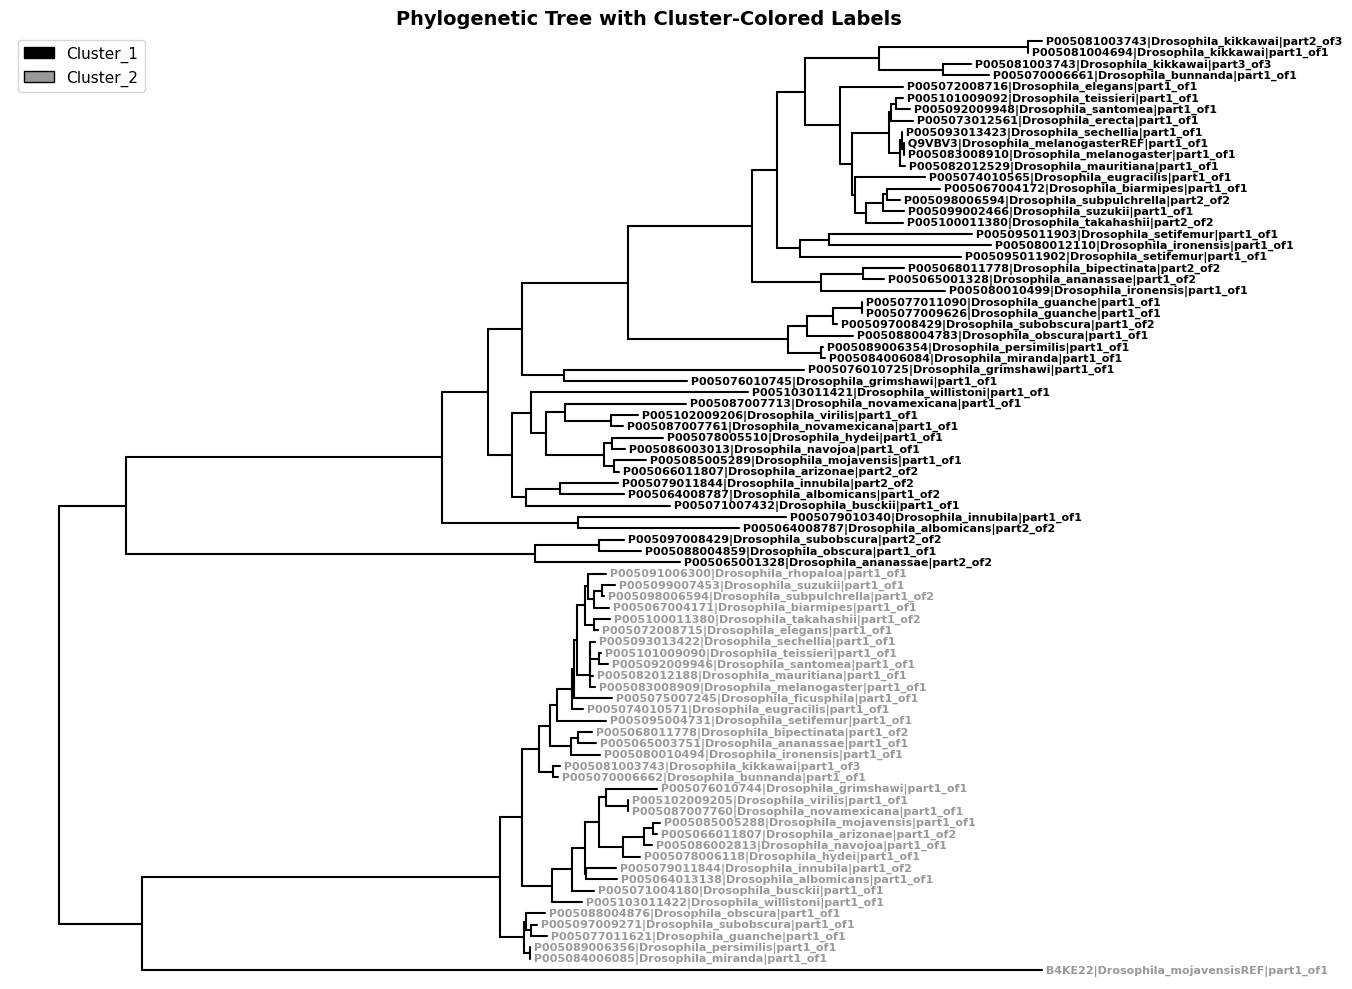

In [34]:
CLUSTER_COLORS = {
    "Cluster_1": "#000000",  # black
    "Cluster_2": "#999999",  # grey
}


def _clean_tree_axes(ax):
    """Remove spines, ticks, and axis labels from a tree plot."""
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


# --- Load and root tree ---
tree = Phylo.read(TREE_FILE, "newick")
if not tree.rooted:
    print("Tree is unrooted — rooting at midpoint...")
    tree.root_at_midpoint()
    print("✓ Tree rooted at midpoint\n")

# --- Identify two main clades ---
main_clades = tree.root.clades
if len(main_clades) != 2:
    print(f"⚠️  Found {len(main_clades)} main clades — using the two largest...")
    main_clades = sorted(tree.get_nonterminals(), key=lambda x: x.count_terminals(), reverse=True)[
        :2
    ]

# --- Build cluster assignments ---
cluster_data = [
    {"tip_label": t.name, "cluster": f"Cluster_{i}"}
    for i, clade in enumerate(main_clades, start=1)
    for t in clade.get_terminals()
]
cluster_df = pd.DataFrame(cluster_data)
cluster_df.to_csv("output_files/cluster_assignments.csv", index=False)

print(f"Total tips: {len(cluster_df)}")
print("\nCluster distribution:")
print(cluster_df["cluster"].value_counts().to_string())
print("\nCluster assignments:")
display(cluster_df)
print("✓ Saved to output_files/cluster_assignments.csv")

# --- Plot tree with colored tip labels ---
tip_to_cluster = dict(zip(cluster_df["tip_label"], cluster_df["cluster"], strict=False))

preview("Tip-to-cluster mapping", tip_to_cluster)

fig, ax = plt.subplots(figsize=(14, 10))
Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    label_func=lambda x: x.name if x.name else "",
    show_confidence=False,
)
_clean_tree_axes(ax)

for text in ax.texts:
    label = text.get_text().strip()
    if label in tip_to_cluster:
        text.set_color(CLUSTER_COLORS[tip_to_cluster[label]])
        text.set_fontweight("bold")
        text.set_fontsize(8)

legend_patches = [
    mpatches.Patch(facecolor=CLUSTER_COLORS[k], edgecolor="black", label=k) for k in CLUSTER_COLORS
]
ax.legend(handles=legend_patches, loc="upper left", fontsize=11, frameon=True)

plt.title("Phylogenetic Tree with Cluster-Colored Labels", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Let's do that again but clearly differentiate the two main clusters from the subgroup containing subobscura, obscura, ananassase, as well as the B4KE22 which appears to be a different gene altogether

Tree is unrooted — rooting at midpoint...
✓ Tree rooted at midpoint

Total tips: 83

Cluster distribution:
cluster
Cluster_1    44
Cluster_2    35
Cluster_3     3
Cluster_4     1

Cluster assignments:


,tip_label,cluster
0,P005081003743|Drosophila_kikkawai|part2_of3,Cluster_1
1,P005081004694|Drosophila_kikkawai|part1_of1,Cluster_1
2,P005081003743|Drosophila_kikkawai|part3_of3,Cluster_1
3,P005070006661|Drosophila_bunnanda|part1_of1,Cluster_1
4,P005072008716|Drosophila_elegans|part1_of1,Cluster_1
...,...,...
78,P005097009271|Drosophila_subobscura|part1_of1,Cluster_2
79,P005077011621|Drosophila_guanche|part1_of1,Cluster_2
80,P005089006356|Drosophila_persimilis|part1_of1,Cluster_2
81,P005084006085|Drosophila_miranda|part1_of1,Cluster_2


✓ Saved to output_files/cluster_assignments.csv

Tip-to-cluster mapping:
  P005081003743|Drosophila_kikkawai|part2_of3 → Cluster_1
  P005081004694|Drosophila_kikkawai|part1_of1 → Cluster_1
  P005081003743|Drosophila_kikkawai|part3_of3 → Cluster_1


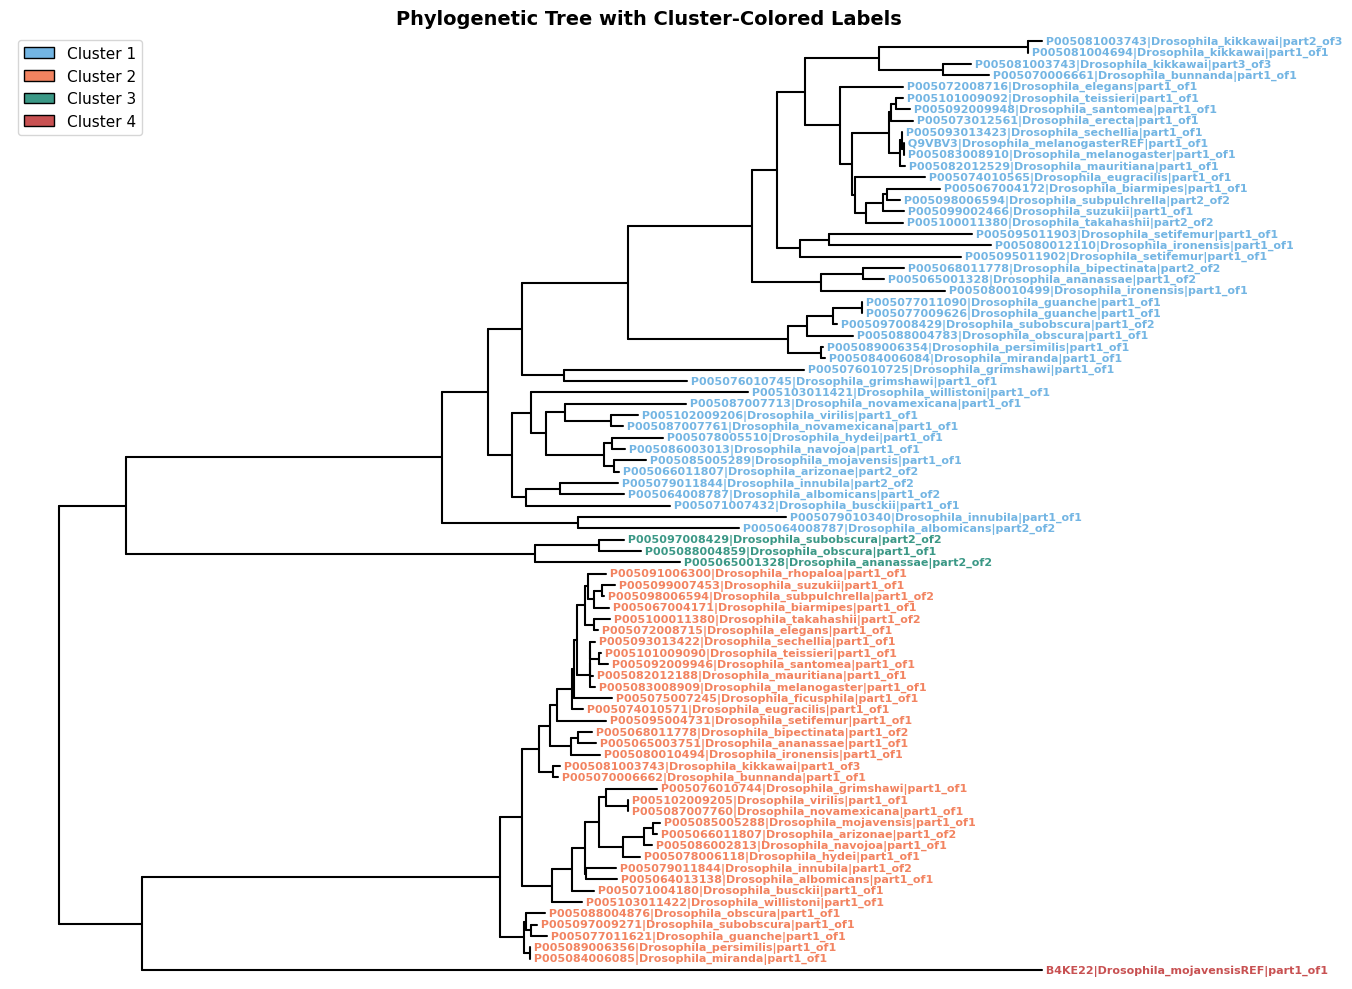

In [35]:
CLUSTER_COLORS = {
    "Cluster_1": "#73b5e3",  # blue
    "Cluster_2": "#F28360",  # orange
    "Cluster_3": "#3B9886",  # green
    "Cluster_4": "#C85152",  # red
}

REASSIGNMENTS = {
    "P005097008429|Drosophila_subobscura|part2_of2": "Cluster_3",
    "P005088004859|Drosophila_obscura|part1_of1": "Cluster_3",
    "P005065001328|Drosophila_ananassae|part2_of2": "Cluster_3",
    "B4KE22|Drosophila_mojavensisREF|part1_of1": "Cluster_4",
}

# --- Load and root tree ---
tree = Phylo.read(TREE_FILE, "newick")
if not tree.rooted:
    print("Tree is unrooted — rooting at midpoint...")
    tree.root_at_midpoint()
    print("✓ Tree rooted at midpoint\n")

# --- Identify two main clades ---
main_clades = tree.root.clades
if len(main_clades) != 2:
    print(f"⚠️  Found {len(main_clades)} main clades — using the two largest...")
    main_clades = sorted(tree.get_nonterminals(), key=lambda x: x.count_terminals(), reverse=True)[
        :2
    ]

# --- Build cluster assignments ---
cluster_data = [
    {"tip_label": t.name, "cluster": f"Cluster_{i}"}
    for i, clade in enumerate(main_clades, start=1)
    for t in clade.get_terminals()
]
cluster_df = pd.DataFrame(cluster_data)
cluster_df["cluster"] = cluster_df.apply(
    lambda row: REASSIGNMENTS.get(row["tip_label"], row["cluster"]), axis=1
)
cluster_df.to_csv("output_files/cluster_assignments.csv", index=False)

print(f"Total tips: {len(cluster_df)}")
print("\nCluster distribution:")
print(cluster_df["cluster"].value_counts().to_string())
print("\nCluster assignments:")
display(cluster_df)
print("✓ Saved to output_files/cluster_assignments.csv")

# --- Plot tree with colored tip labels ---
tip_to_cluster = dict(zip(cluster_df["tip_label"], cluster_df["cluster"], strict=False))
preview("Tip-to-cluster mapping", tip_to_cluster)

fig, ax = plt.subplots(figsize=(14, 10))
Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    label_func=lambda x: x.name if x.name else "",
    show_confidence=False,
)
_clean_tree_axes(ax)

for text in ax.texts:
    cluster = tip_to_cluster.get(text.get_text().strip())
    if cluster:
        text.set_color(CLUSTER_COLORS[cluster])
        text.set_fontweight("bold")
        text.set_fontsize(8)

legend_patches = [
    mpatches.Patch(
        facecolor=CLUSTER_COLORS[f"Cluster_{i}"], edgecolor="black", label=f"Cluster {i}"
    )
    for i in range(1, 5)
]
ax.legend(handles=legend_patches, loc="upper left", fontsize=11, frameon=True)

plt.title("Phylogenetic Tree with Cluster-Colored Labels", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 11: BLASTp of Representative Sequences

In [36]:
# --- Configuration ---
PROTEOME_ID = "UP000000803"
DB_DIR = "blast_db"
DB_NAME = os.path.join(DB_DIR, "dmel_uniprot")
UNIPROT_URL = (
    f"https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=(proteome:{PROTEOME_ID})"
)
UNIPROT_FASTA = os.path.join(DB_DIR, "dmel_uniprot.fasta")

os.makedirs(DB_DIR, exist_ok=True)

print(f"{'='*60}\nDOWNLOADING D. MELANOGASTER UNIPROT DATABASE ({PROTEOME_ID})\n{'='*60}")
print(f"  Database directory: {DB_DIR}")

# --- Download proteome FASTA ---
print("\nDownloading D. melanogaster proteome from UniProt (this may take 1-2 minutes)...")
try:
    urllib.request.urlretrieve(UNIPROT_URL, UNIPROT_FASTA)
except Exception as e:
    print(f"✗ Download failed: {e}")
    print("  Check your connection, verify the proteome ID, and ensure BLAST+ is installed:")
    print("    conda install -c bioconda blast")
    raise

if not os.path.exists(UNIPROT_FASTA) or os.path.getsize(UNIPROT_FASTA) == 0:
    raise RuntimeError("Downloaded file is missing or empty.")

file_size = os.path.getsize(UNIPROT_FASTA) / (1024 * 1024)
with open(UNIPROT_FASTA) as fh:
    seq_count = sum(1 for line in fh if line.startswith(">"))

print(f"✓ Downloaded {seq_count} sequences ({file_size:.1f} MB)")

# --- Build BLAST database ---
print(f"\n{'='*60}\nCreating BLAST database...\n{'='*60}")

result = subprocess.run(
    [
        "makeblastdb",
        "-in",
        UNIPROT_FASTA,
        "-dbtype",
        "prot",
        "-out",
        DB_NAME,
        "-title",
        f"D. melanogaster UniProt Proteins ({PROTEOME_ID})",
        "-parse_seqids",
    ],
    capture_output=True,
    text=True,
)

if result.returncode == 0:
    print(f"✓ BLAST database created: {DB_NAME}.*")
    print(f'\nSet in config: BLAST_DATABASE = "{DB_NAME}"')
    with open(UNIPROT_FASTA) as fh:
        headers = [line.strip() for line in fh if line.startswith(">")]
    preview("First sequence headers", headers[:3])
else:
    print(f"✗ Failed to create BLAST database:\n{result.stderr}")

DOWNLOADING D. MELANOGASTER UNIPROT DATABASE (UP000000803)
  Database directory: blast_db

✓ Downloaded 22019 sequences (16.8 MB)

Creating BLAST database...
✓ BLAST database created: blast_db/dmel_uniprot.*

Set in config: BLAST_DATABASE = "blast_db/dmel_uniprot"

First sequence headers:
  >>tr|A0A021WW32|A0A021WW32_DROME Verthandi, isoform B OS=Drosophila melanogaster OX=7227 GN=vtd PE=1 SV=1
  >>tr|A0A023GRW4|A0A023GRW4_DROME Terribly reduced optic lobes, isoform AZ OS=Drosophila melanogaster OX=7227 GN=trol PE=1 SV=1
  >>tr|A0A0B4JCQ5|A0A0B4JCQ5_DROME phosphatidate phosphatase OS=Drosophila melanogaster OX=7227 GN=Lpin PE=1 SV=1


In [37]:
# --- Parameters ---
BLAST_DATABASE = "blast_db/dmel_uniprot"
EVALUE_CUTOFF = 1e-5
NUM_THREADS = 4

TARGET_SPECIES = [
    "Drosophila_melanogaster",
    "Drosophila_obscura",
    "Drosophila_mojavensisREF",
]

BLAST_COLUMNS = [
    "qseqid",
    "sseqid",
    "pident",
    "length",
    "mismatch",
    "gapopen",
    "qstart",
    "qend",
    "sstart",
    "send",
    "evalue",
    "bitscore",
]


# --- Build UniProt ID → gene name / description mapping ---
def load_uniprot_gene_map(fasta_path):
    """
    Parse a UniProt FASTA file to build ID → gene name and description mappings.

    Parameters
    ----------
    fasta_path : str
        Path to the UniProt FASTA file.

    Returns
    -------
    tuple of (dict, dict)
        id_to_gene and id_to_description mappings.
    """
    id_to_gene, id_to_desc = {}, {}
    with open(fasta_path) as fh:
        for line in fh:
            if not line.startswith(">"):
                continue
            parts = line.strip().split()
            uid = parts[0].split("|")[1] if "|" in parts[0] else parts[0].lstrip(">")

            gene = next((p.split("=")[1] for p in parts if p.startswith("GN=")), uid)
            desc_parts = []
            for p in parts[1:]:
                if p.startswith("OS="):
                    break
                desc_parts.append(p)
            desc = " ".join(desc_parts) or "No description"

            id_to_gene[uid] = gene
            id_to_desc[uid] = desc
    return id_to_gene, id_to_desc


def extract_gene_info(sseqid, id_to_gene, id_to_desc):
    """Look up gene name and description for a BLAST hit ID."""
    uid = sseqid.split("|")[1] if "|" in sseqid else sseqid
    return pd.Series(
        {
            "gene_name": id_to_gene.get(uid, uid),
            "description": id_to_desc.get(uid, ""),
        }
    )


# --- Load gene map ---
uniprot_fasta = os.path.join("blast_db", "dmel_uniprot.fasta")
if os.path.exists(uniprot_fasta):
    id_to_gene, id_to_desc = load_uniprot_gene_map(uniprot_fasta)
    print(f"✓ Loaded {len(id_to_gene)} gene name mappings")
else:
    id_to_gene, id_to_desc = {}, {}
    print(f"⚠️  Could not find {uniprot_fasta} — gene names will not be available")


# --- Extract target sequences ---
all_sequences = {}
for species in TARGET_SPECIES:
    seqs = [
        r for r in SeqIO.parse(INPUT_FASTA, "fasta") if species in r.id or species in r.description
    ]
    if seqs:
        print(f"✓ Found {len(seqs)} sequence(s) for '{species}'")
        preview(f"  {species}", [r.id for r in seqs])
    else:
        print(f"⚠️  No sequences found for '{species}'")
    all_sequences[species] = seqs


# --- Run BLASTp ---
total_searched = 0

for species, seqs in all_sequences.items():
    print(f"\n{'='*60}\nSpecies: {species.replace('_', ' ')}\n{'='*60}")

    for idx, seq in enumerate(seqs, start=1):
        print(f"\nSequence {idx}/{len(seqs)}: {seq.id}")

        temp_query = f"temp_query_{idx}.fasta"
        safe_id = seq.id.replace("|", "_")
        output_file = f"blastp_output/blast_results_{safe_id}.txt"

        SeqIO.write([seq], temp_query, "fasta")

        result = subprocess.run(
            [
                "blastp",
                "-query",
                temp_query,
                "-db",
                BLAST_DATABASE,
                "-out",
                output_file,
                "-outfmt",
                "6",
                "-evalue",
                str(EVALUE_CUTOFF),
                "-num_threads",
                str(NUM_THREADS),
            ],
            capture_output=True,
            text=True,
        )

        if os.path.exists(temp_query):
            os.remove(temp_query)

        if result.returncode != 0:
            print(f"  ✗ BLAST failed: {result.stderr}")
            continue

        if not os.path.exists(output_file) or os.path.getsize(output_file) == 0:
            print("  No hits found")
            continue

        blast_df = pd.read_csv(output_file, sep="\t", header=None, names=BLAST_COLUMNS)
        blast_df[["gene_name", "description"]] = blast_df["sseqid"].apply(
            extract_gene_info, args=(id_to_gene, id_to_desc)
        )

        print(f"  ✓ BLAST complete — {len(blast_df)} hits")
        print("\n  Top 5 hits:")
        display(blast_df.head(5)[["sseqid", "gene_name", "pident", "evalue", "bitscore"]])

        print("\n  Top hit details:")
        for i, row in blast_df.head(5).iterrows():
            print(f"    {i+1}. {row['gene_name']}: {row['description']}")
            print(f"       Identity: {row['pident']:.1f}%  E-value: {row['evalue']:.2e}")

        enriched_output = output_file.replace(".txt", "_with_genes.csv")
        blast_df.to_csv(enriched_output, index=False)
        print(f"\n  ✓ Saved enriched results to: {enriched_output}")

        total_searched += 1

print(f"\n{'='*60}\nBLAST SEARCH COMPLETE\n{'='*60}")
print(f"  Searched {total_searched} sequence(s) across {len(all_sequences)} species")
print("  Results saved to *_with_genes.csv files")

✓ Loaded 22019 gene name mappings
✓ Found 3 sequence(s) for 'Drosophila_melanogaster'

  Drosophila_melanogaster:
  >P005083008910|Drosophila_melanogaster
  >P005083008909|Drosophila_melanogaster
  >Q9VBV3|Drosophila_melanogasterREF
✓ Found 4 sequence(s) for 'Drosophila_obscura'

  Drosophila_obscura:
  >P005088004876|Drosophila_obscura
  >P005088004783|Drosophila_obscura
  >P005088004351|Drosophila_obscura
✓ Found 1 sequence(s) for 'Drosophila_mojavensisREF'

  Drosophila_mojavensisREF:
  >B4KE22|Drosophila_mojavensisREF

Species: Drosophila melanogaster

Sequence 1/3: P005083008910|Drosophila_melanogaster
  ✓ BLAST complete — 24 hits

  Top 5 hits:


,sseqid,gene_name,pident,evalue,bitscore
0,A0A0B4LHM9,to,100.000,0.000000e+00,508.0
1,Q9VBV3,to,100.000,0.000000e+00,508.0
2,Q9VBV4,Jhbp7,30.645,5.400000e-39,135.0
3,Q9VBV1,Dmel\CG11854,31.304,1.380000e-36,129.0
4,O76879,dyw,29.134,2.170000e-33,121.0



  Top hit details:
    1. to: Takeout, isoform B
       Identity: 100.0%  E-value: 0.00e+00
    2. to: Protein takeout
       Identity: 100.0%  E-value: 0.00e+00
    3. Jhbp7: Juvenile hormone binding protein 7
       Identity: 30.6%  E-value: 5.40e-39
    4. Dmel\CG11854: Protein takeout
       Identity: 31.3%  E-value: 1.38e-36
    5. dyw: Circadian clock-controlled protein daywake
       Identity: 29.1%  E-value: 2.17e-33

  ✓ Saved enriched results to: blastp_output/blast_results_P005083008910_Drosophila_melanogaster_with_genes.csv

Sequence 2/3: P005083008909|Drosophila_melanogaster
  ✓ BLAST complete — 26 hits

  Top 5 hits:


,sseqid,gene_name,pident,evalue,bitscore
0,Q9VBV4,Jhbp7,100.000,0.000000e+00,519.0
1,Q9VBV1,Dmel\CG11854,34.400,2.920000e-45,152.0
2,A0A0B4LHM9,to,30.645,5.430000e-39,135.0
3,Q9VBV3,to,30.645,5.430000e-39,135.0
4,Q9VEZ6,Jhbp5,29.870,1.560000e-35,127.0



  Top hit details:
    1. Jhbp7: Juvenile hormone binding protein 7
       Identity: 100.0%  E-value: 0.00e+00
    2. Dmel\CG11854: Protein takeout
       Identity: 34.4%  E-value: 2.92e-45
    3. to: Takeout, isoform B
       Identity: 30.6%  E-value: 5.43e-39
    4. to: Protein takeout
       Identity: 30.6%  E-value: 5.43e-39
    5. Jhbp5: Juvenile hormone binding protein 5, isoform A
       Identity: 29.9%  E-value: 1.56e-35

  ✓ Saved enriched results to: blastp_output/blast_results_P005083008909_Drosophila_melanogaster_with_genes.csv

Sequence 3/3: Q9VBV3|Drosophila_melanogasterREF
  ✓ BLAST complete — 24 hits

  Top 5 hits:


...


  Top hit details:
    1. to: Takeout, isoform B
       Identity: 59.6%  E-value: 1.18e-38
    2. to: Protein takeout
       Identity: 59.6%  E-value: 1.18e-38
    3. Jhbp7: Juvenile hormone binding protein 7
       Identity: 30.7%  E-value: 1.07e-08
    4. Dmel\CG11854: Protein takeout
       Identity: 31.5%  E-value: 1.20e-06

  ✓ Saved enriched results to: blastp_output/blast_results_P005088004351_Drosophila_obscura_with_genes.csv

Sequence 4/4: P005088004859|Drosophila_obscura
  ✓ BLAST complete — 27 hits

  Top 5 hits:


,sseqid,gene_name,pident,evalue,bitscore
0,Q9VBV1,Dmel\CG11854,64.490,1.460000e-118,338.0
1,Q9VBV4,Jhbp7,34.677,4.230000e-47,157.0
2,A0A0B4LHM9,to,29.555,6.620000e-38,133.0
3,Q9VBV3,to,29.555,6.620000e-38,133.0
4,Q9VC67,Jhbp12,29.787,2.250000e-33,121.0



  Top hit details:
    1. Dmel\CG11854: Protein takeout
       Identity: 64.5%  E-value: 1.46e-118
    2. Jhbp7: Juvenile hormone binding protein 7
       Identity: 34.7%  E-value: 4.23e-47
    3. to: Takeout, isoform B
       Identity: 29.6%  E-value: 6.62e-38
    4. to: Protein takeout
       Identity: 29.6%  E-value: 6.62e-38
    5. Jhbp12: Juvenile hormone binding protein 12
       Identity: 29.8%  E-value: 2.25e-33

  ✓ Saved enriched results to: blastp_output/blast_results_P005088004859_Drosophila_obscura_with_genes.csv

Species: Drosophila mojavensisREF

Sequence 1/1: B4KE22|Drosophila_mojavensisREF
  ✓ BLAST complete — 22 hits

  Top 5 hits:


,sseqid,gene_name,pident,evalue,bitscore
0,Q9VDF8,Dmel\CG31189,52.381,3.190000e-93,275.0
1,Q8MSJ6,CG7096,46.748,8.940000e-82,245.0
2,Q9VDF7,Dmel\CG7079,44.664,2.600000e-77,234.0
3,Q9VDF6,Jhbp15,32.114,2.280000e-37,131.0
4,Q9VBV4,Jhbp7,26.639,3.040000e-30,113.0



  Top hit details:
    1. Dmel\CG31189: Protein takeout
       Identity: 52.4%  E-value: 3.19e-93
    2. CG7096: GH08336p
       Identity: 46.7%  E-value: 8.94e-82
    3. Dmel\CG7079: IP10158p
       Identity: 44.7%  E-value: 2.60e-77
    4. Jhbp15: Juvenile hormone binding protein 15
       Identity: 32.1%  E-value: 2.28e-37
    5. Jhbp7: Juvenile hormone binding protein 7
       Identity: 26.6%  E-value: 3.04e-30

  ✓ Saved enriched results to: blastp_output/blast_results_B4KE22_Drosophila_mojavensisREF_with_genes.csv

BLAST SEARCH COMPLETE
  Searched 8 sequence(s) across 3 species
  Results saved to *_with_genes.csv files


Get the gene names of our top hits: Q9VBV3, Q9VBV4, Q9VBV1, and Q9VDF8

Processing Q9VBV3...
Processing Q9VBV4...
Processing Q9VBV1...
Processing Q9VDF8...

✓ Done



,uniprot_id,gene_name,FBgn,chrom,start,end,strand
0,Q9VBV3,to,FBgn0039298,3R,25240180,25241668,+
1,Q9VBV4,Jhbp7,FBgn0039297,3R,25237614,25238895,+
2,Q9VBV1,Dmel\CG11854,FBgn0039299,3R,25242020,25243262,+
3,Q9VDF8,Dmel\CG31189,FBgn0051189,3R,21044898,21045842,-


Found 2 group(s) based on 100,000 bp gap threshold


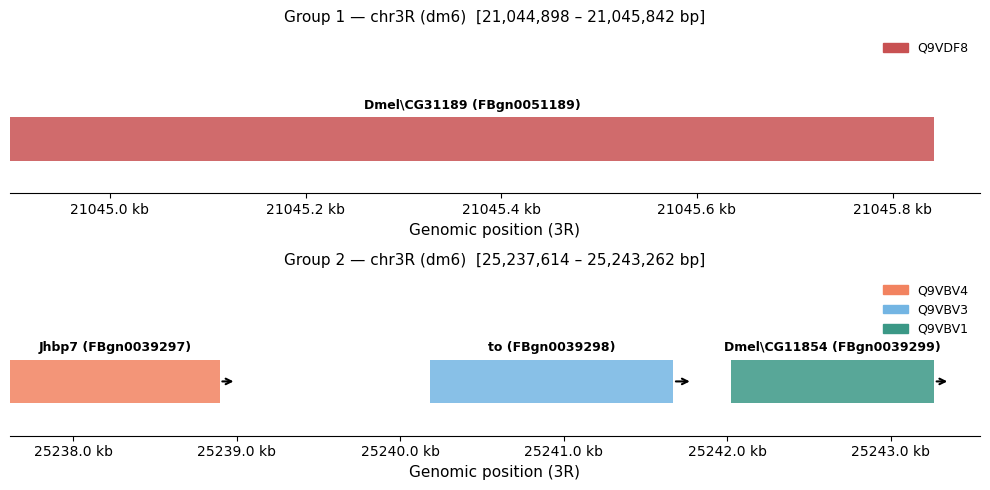

In [38]:
# --- Parameters ---
UNIPROT_IDS = ["Q9VBV3", "Q9VBV4", "Q9VBV1", "Q9VDF8"]
GAP_THRESHOLD = 100_000
GENE_COLORS = ["#C85152", "#F28360", "#73b5e3", "#3B9886"]  # red, green, blue, orange


# --- Helpers ---
def uniprot_to_gene_id(accession):
    """
    Fetch gene name and FlyBase ID for a UniProt accession.

    Parameters
    ----------
    accession : str
        UniProt accession (e.g. 'Q9VBV3').

    Returns
    -------
    dict
        Keys: 'gene_name', 'FBgn'.
    """
    r = requests.get(f"https://rest.uniprot.org/uniprotkb/{accession}.json", timeout=15)
    r.raise_for_status()
    data = r.json()
    gene_name = data.get("genes", [{}])[0].get("geneName", {}).get("value", "N/A")
    fbgn = next(
        (
            x["id"]
            for x in data.get("uniProtKBCrossReferences", [])
            if x["database"] == "FlyBase" and x["id"].startswith("FBgn")
        ),
        None,
    )
    return {"gene_name": gene_name, "FBgn": fbgn}


def fbgn_to_genomic_coords(fbgn):
    """
    Retrieve genomic coordinates for a FlyBase gene ID via MyGene.info.

    Parameters
    ----------
    fbgn : str
        FlyBase gene ID (e.g. 'FBgn0001234').

    Returns
    -------
    dict
        Keys: 'chrom', 'start', 'end', 'strand'.
    """
    empty = {"chrom": "N/A", "start": "N/A", "end": "N/A", "strand": "N/A"}
    r = requests.get(
        "https://mygene.info/v3/query",
        params={"q": f"flybase:{fbgn}", "species": "fruitfly", "fields": "genomic_pos"},
        timeout=15,
    )
    if r.status_code != 200:
        return empty
    hits = r.json().get("hits", [])
    if not hits:
        return empty
    pos = hits[0].get("genomic_pos")
    if not pos:
        return empty
    if isinstance(pos, list):
        pos = pos[0]
    return {
        "chrom": pos.get("chr", "N/A"),
        "start": pos.get("start", "N/A"),
        "end": pos.get("end", "N/A"),
        "strand": {1: "+", -1: "-"}.get(pos.get("strand"), "N/A"),
    }


def draw_gene(ax, x, y, length, strand, label, color, bar_height=0.4):
    """
    Draw a gene bar with strand arrow and label onto an axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    x, y : float
        Bottom-left position of the gene bar.
    length : int
        Gene length in base pairs.
    strand : str
        '+' or '-'.
    label : str
        Text label drawn above the bar.
    color : str
        Bar fill color.
    bar_height : float
        Height of the gene bar.
    """
    ax.barh(y, length, left=x, height=bar_height, color=color, alpha=0.85)
    arrow_x = x + length if strand == "+" else x
    dx = length * 0.08 * (1 if strand == "+" else -1)
    ax.annotate(
        "",
        xy=(arrow_x + dx, y),
        xytext=(arrow_x, y),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    )
    ax.text(
        x + length / 2,
        y + bar_height / 2 + 0.05,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )


def _format_kb(x, _):
    return f"{x / 1e3:.1f} kb"


def _clean_gene_axes(ax):
    """Remove top, right, and left spines and y-ticks from a gene plot."""
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.yaxis.set_tick_params(length=0)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(_format_kb))


# --- Fetch coordinates ---
records = []
for acc in UNIPROT_IDS:
    print(f"Processing {acc}...")
    info = uniprot_to_gene_id(acc)
    coords = (
        fbgn_to_genomic_coords(info["FBgn"])
        if info["FBgn"]
        else {"chrom": "N/A", "start": "N/A", "end": "N/A", "strand": "N/A"}
    )
    records.append(
        {"uniprot_id": acc, "gene_name": info["gene_name"], "FBgn": info["FBgn"], **coords}
    )

df = pd.DataFrame(records)
chrom = df["chrom"].iloc[0]
print("\n✓ Done\n")
display(df)


# --- Plot 1: genes grouped by proximity ---
valid = (
    df[(df["start"] != "N/A") & (df["end"] != "N/A")]
    .copy()
    .assign(start=lambda d: d["start"].astype(int), end=lambda d: d["end"].astype(int))
    .sort_values("start")
    .reset_index(drop=True)
)

groups, current = [], [valid.iloc[0]]
for i in range(1, len(valid)):
    if valid.iloc[i]["start"] - valid.iloc[i - 1]["end"] > GAP_THRESHOLD:
        groups.append(pd.DataFrame(current))
        current = [valid.iloc[i]]
    else:
        current.append(valid.iloc[i])
groups.append(pd.DataFrame(current))
print(f"Found {len(groups)} group(s) based on {GAP_THRESHOLD:,} bp gap threshold")

color_map = {row["uniprot_id"]: GENE_COLORS[i % len(GENE_COLORS)] for i, row in valid.iterrows()}

fig2, axes = plt.subplots(len(groups), 1, figsize=(10, 2.5 * len(groups)), squeeze=False)
for g_idx, (group, ax) in enumerate(zip(groups, axes[:, 0], strict=False)):
    for _, row in group.iterrows():
        draw_gene(
            ax,
            row["start"],
            0,
            row["end"] - row["start"],
            row["strand"],
            f"{row['gene_name']} ({row['FBgn']})",
            color_map[row["uniprot_id"]],
        )

    ax.set_xlabel(f"Genomic position ({chrom})", fontsize=11)
    ax.set_yticks([])
    ax.set_ylim(-0.5, 1.0)
    ax.set_title(
        f"Group {g_idx + 1} — chr{chrom} (dm6)  "
        f"[{group['start'].min():,} – {group['end'].max():,} bp]",
        fontsize=11,
    )
    _clean_gene_axes(ax)
    ax.legend(
        handles=[
            mpatches.Patch(color=color_map[r["uniprot_id"]], label=r["uniprot_id"])
            for _, r in group.iterrows()
        ],
        loc="upper right",
        fontsize=9,
        frameon=False,
    )

plt.tight_layout()
plt.show()

## Step 12: Calculate Sequence-Based Distances Across Aligned Domains

For our end comparison we need pairwise sequence similarity/dissimilarity and pairwise patristic distances in the phylogenetic tree so we calculate those here. Sequence-sequence similarity/distances and patristic distances are symmetrical so are only reported in one direction

In [39]:
def _print_stats(label, series, fmt=".3f"):
    """Print summary statistics for a pandas Series."""
    print(f"\n{label} statistics:")
    for stat, val in [
        ("Mean", series.mean()),
        ("Median", series.median()),
        ("Min", series.min()),
        ("Max", series.max()),
    ]:
        print(f"  {stat+':':8s} {val:{fmt}}")


def calculate_pairwise_identity(aligned_fasta):
    """
    Calculate pairwise sequence identity for all aligned sequences.

    Identity is computed over non-gap columns only (1 - divergence).

    Parameters
    ----------
    aligned_fasta : str
        Path to the aligned FASTA file.

    Returns
    -------
    pd.DataFrame
        Pairwise comparisons with columns: seq1, seq2, identity, divergence.
    """
    alignment = AlignIO.read(aligned_fasta, "fasta")
    sequences = {rec.id: str(rec.seq) for rec in alignment}
    ids = list(sequences.keys())

    print(f"Calculating pairwise sequence identity for {len(ids)} sequences...")

    results = []
    for i, id1 in enumerate(ids):
        for id2 in ids[i + 1 :]:
            pairs = [
                (a, b)
                for a, b in zip(sequences[id1], sequences[id2], strict=False)
                if a != "-" and b != "-"
            ]
            comparisons = len(pairs)
            identity = sum(a == b for a, b in pairs) / comparisons if comparisons else 0
            results.append(
                {"seq1": id1, "seq2": id2, "identity": identity, "divergence": 1 - identity}
            )

    df = pd.DataFrame(results)
    print(f"✓ Calculated {len(df)} pairwise comparisons")
    _print_stats("Sequence identity", df["identity"])
    return df


def calculate_patristic_distances(tree_file):
    """
    Calculate pairwise patristic distances from a phylogenetic tree.

    Parameters
    ----------
    tree_file : str
        Path to the Newick tree file.

    Returns
    -------
    pd.DataFrame
        Pairwise comparisons with columns: seq1, seq2, patristic_distance.
    """
    tree = Phylo.read(tree_file, "newick")
    terminals = tree.get_terminals()

    print(f"Calculating patristic distances for {len(terminals)} sequences...")

    results = [
        {"seq1": t1.name, "seq2": t2.name, "patristic_distance": tree.distance(t1, t2)}
        for i, t1 in enumerate(terminals)
        for t2 in terminals[i + 1 :]
    ]

    df = pd.DataFrame(results)
    print(f"✓ Calculated {len(df)} pairwise distances")
    _print_stats("Patristic distance", df["patristic_distance"], fmt=".4f")
    return df

In [40]:
# Calculate sequence-based distances
seq_identity_df = calculate_pairwise_identity(DOMAIN_ALIGNED)
patristic_df = calculate_patristic_distances(TREE_FILE)

# Display first few rows
print("\nSequence identity data:")
display(seq_identity_df.head())

print("\nPatristic distance data:")
display(patristic_df.head())

Calculating pairwise sequence identity for 83 sequences...
✓ Calculated 3403 pairwise comparisons

Sequence identity statistics:
  Mean:    0.481
  Median:  0.335
  Min:     0.186
  Max:     1.000
Calculating patristic distances for 83 sequences...
✓ Calculated 3403 pairwise distances

Patristic distance statistics:
  Mean:    1.5472
  Median:  1.9583
  Min:     0.0000
  Max:     3.4989

Sequence identity data:


,seq1,seq2,identity,divergence
0,B4KE22|Drosophila_mojavensisREF|part1_of1,P005064008787|Drosophila_albomicans|part1_of2,0.211382,0.788618
1,B4KE22|Drosophila_mojavensisREF|part1_of1,P005064008787|Drosophila_albomicans|part2_of2,0.200000,0.800000
2,B4KE22|Drosophila_mojavensisREF|part1_of1,P005064013138|Drosophila_albomicans|part1_of1,0.244898,0.755102
3,B4KE22|Drosophila_mojavensisREF|part1_of1,P005065001328|Drosophila_ananassae|part1_of2,0.230769,0.769231
4,B4KE22|Drosophila_mojavensisREF|part1_of1,P005065001328|Drosophila_ananassae|part2_of2,0.221774,0.778226



Patristic distance data:


,seq1,seq2,patristic_distance
0,P005083008909|Drosophila_melanogaster|part1_of1,P005082012188|Drosophila_mauritiana|part1_of1,0.011609
1,P005083008909|Drosophila_melanogaster|part1_of1,P005092009946|Drosophila_santomea|part1_of1,0.039052
2,P005083008909|Drosophila_melanogaster|part1_of1,P005101009090|Drosophila_teissieri|part1_of1,0.027331
3,P005083008909|Drosophila_melanogaster|part1_of1,P005093013422|Drosophila_sechellia|part1_of1,0.015513
4,P005083008909|Drosophila_melanogaster|part1_of1,P005075007245|Drosophila_ficusphila|part1_of1,0.103645


## Step 13: Calculate Protein Structural Similarity (TM-scores)

Now we can finally calculate pairwise structural similarity across equivalent domains using TM-align. The resulting TM-scores are asymmetrical (since a query and target are specified) and so calculated for each pair in each direction

In [41]:
def load_excluded_proteins(excluded_file="output_files/removed_partial_domains.txt"):
    """
    Load excluded protein IDs from the removed domains file.

    Parameters
    ----------
    excluded_file : str
        Path to the file written by extract_domain_alignments().

    Returns
    -------
    set of str
        Protein IDs to exclude from analysis.
    """
    if not os.path.exists(excluded_file):
        print(f"No exclusion file found at {excluded_file}")
        return set()

    with open(excluded_file) as fh:
        excluded = {line.split("|")[0].lstrip(">") for line in fh if line.startswith(">")}

    print(f"Loaded {len(excluded)} excluded protein IDs from {excluded_file}")
    preview("Examples", list(excluded)[:3])
    return excluded


def run_tmalign(pdb1, pdb2):
    """
    Run TM-align between two PDB files.

    Parameters
    ----------
    pdb1, pdb2 : str
        Paths to the PDB files to compare.

    Returns
    -------
    float or None
        TM-score normalised by the first structure, or None on failure.
    """
    try:
        result = subprocess.run(["TMalign", pdb1, pdb2], capture_output=True, text=True, check=True)
        for line in result.stdout.split("\n"):
            if "TM-score=" in line and "Chain_1" in line:
                return float(line.split("TM-score=")[1].split()[0])
        return None
    except subprocess.CalledProcessError:
        return None


def calculate_all_tm_scores(
    pdb_dir, pdb_extension=".pdb", excluded_file="output_files/removed_partial_domains.txt"
):
    """
    Calculate pairwise TM-scores for all PDB files in a directory.

    TM-scores are asymmetric so both directions are computed. Proteins
    listed in excluded_file are skipped.

    Parameters
    ----------
    pdb_dir : str
        Directory containing domain PDB files.
    pdb_extension : str
        File extension to filter PDB files.
    excluded_file : str
        Path to the exclusion list from extract_domain_alignments().

    Returns
    -------
    pd.DataFrame
        Pairwise TM-scores with columns: pdb1, pdb2, tm_score.
    """
    excluded = load_excluded_proteins(excluded_file)

    all_files = [f for f in os.listdir(pdb_dir) if f.endswith(pdb_extension)]
    pdb_files, excluded_count = [], 0

    for f in all_files:
        pid = os.path.splitext(f)[0].split("_")[0]
        if pid in excluded:
            print(f"  Excluding: {f}")
            excluded_count += 1
        else:
            pdb_files.append(f)

    pdb_files = sorted(pdb_files)
    n = len(pdb_files)

    print("\nPDB file statistics:")
    print(f"  Total found:    {len(all_files)}")
    print(f"  Excluded:       {excluded_count}")
    print(f"  Retained:       {n}")
    print(f"  Comparisons:    {n * (n - 1)}")

    if n == 0:
        print("⚠️  No PDB files remaining after exclusions!")
        return pd.DataFrame()

    results = []
    total, count = n * (n - 1), 0
    print("\nCalculating TM-scores...")

    for i, f1 in enumerate(pdb_files):
        for j, f2 in enumerate(pdb_files):
            if i == j:
                continue
            count += 1
            if count % 10 == 0 or count == total:
                print(f"  Progress: {count}/{total} ({100 * count / total:.1f}%)", end="\r")

            tm = run_tmalign(os.path.join(pdb_dir, f1), os.path.join(pdb_dir, f2))
            if tm is not None:
                results.append(
                    {
                        "pdb1": os.path.splitext(f1)[0],
                        "pdb2": os.path.splitext(f2)[0],
                        "tm_score": tm,
                    }
                )

    print()
    df = pd.DataFrame(results)
    print(f"\n✓ Calculated {len(df)} TM-scores")
    if not df.empty:
        _print_stats("TM-score", df["tm_score"])
    return df

In [42]:
# Test the exclusion loading
excluded = load_excluded_proteins("output_files/removed_partial_domains.txt")
print(f"Excluded proteins: {excluded}")

# Then run TM-align
tm_scores_df = calculate_all_tm_scores("pdb_domains")
display(tm_scores_df.head(10))

Loaded 2 excluded protein IDs from output_files/removed_partial_domains.txt

Examples:
  >P005102009207
  >P005088004351
Excluded proteins: {'P005102009207', 'P005088004351'}
Loaded 2 excluded protein IDs from output_files/removed_partial_domains.txt

Examples:
  >P005102009207
  >P005088004351
  Excluding: P005102009207_Drosophila_virilis_part1_of1.pdb
  Excluding: P005088004351_Drosophila_obscura_part1_of1.pdb

PDB file statistics:
  Total found:    85
  Excluded:       2
  Retained:       83
  Comparisons:    6806

Calculating TM-scores...
  Progress: 6806/6806 (100.0%)

✓ Calculated 6806 TM-scores

TM-score statistics:
  Mean:    0.892
  Median:  0.891
  Min:     0.735
  Max:     0.997


,pdb1,pdb2,tm_score
0,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064008787_Drosophila_albomicans_part1_of2,0.91747
1,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064008787_Drosophila_albomicans_part2_of2,0.85522
2,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064013138_Drosophila_albomicans_part1_of1,0.84949
3,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065001328_Drosophila_ananassae_part1_of2,0.86934
4,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065001328_Drosophila_ananassae_part2_of2,0.86445
5,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065003751_Drosophila_ananassae_part1_of1,0.87467
6,B4KE22_Drosophila_mojavensisREF_part1_of1,P005066011807_Drosophila_arizonae_part1_of2,0.85451
7,B4KE22_Drosophila_mojavensisREF_part1_of1,P005066011807_Drosophila_arizonae_part2_of2,0.81716
8,B4KE22_Drosophila_mojavensisREF_part1_of1,P005067004171_Drosophila_biarmipes_part1_of1,0.85445
9,B4KE22_Drosophila_mojavensisREF_part1_of1,P005067004172_Drosophila_biarmipes_part1_of1,0.87933


## Step 14: Integrate Metrics

In [43]:
def _build_pdb_to_seq_map(all_pdb_names, all_seq_names):
    """
    Map PDB filenames to FASTA sequence IDs.

    PDB format:  P005064008787_Drosophila_albomicans_part1_of2
    FASTA format: P005064008787|Drosophila_albomicans|...|part1_of2

    Parameters
    ----------
    all_pdb_names : iterable of str
    all_seq_names : iterable of str

    Returns
    -------
    dict
        pdb_name → seq_name
    """
    # Build a lookup keyed by (protein_id, species, part_info)
    seq_index = {}
    for seq in all_seq_names:
        parts = seq.split("|")
        if len(parts) < 2:
            continue
        pid = parts[0]
        species = parts[1]
        part = next((p for p in parts if p.startswith("part")), None)
        seq_index[(pid, species, part)] = seq

    mapping = {}
    for pdb in all_pdb_names:
        if "_part" in pdb:
            part_idx = pdb.find("_part")
            pid = pdb.split("_")[0]
            species = pdb[len(pid) + 1 : part_idx]
            part = pdb[part_idx + 1 :]
        else:
            pid = pdb.split("_")[0]
            species = "_".join(pdb.split("_")[1:])
            part = "part1_of1"

        match = seq_index.get((pid, species, part))
        if match:
            mapping[pdb] = match

    return mapping


def integrate_all_metrics(seq_identity_df, patristic_df, tm_scores_df):
    """
    Combine pairwise TM-scores, sequence divergence, and patristic distances.

    Parameters
    ----------
    seq_identity_df : pd.DataFrame
        Output of calculate_pairwise_identity().
    patristic_df : pd.DataFrame
        Output of calculate_patristic_distances().
    tm_scores_df : pd.DataFrame
        Output of calculate_all_tm_scores().

    Returns
    -------
    pd.DataFrame
        Integrated metrics with columns: protein1, protein2, tm_score,
        sequence_divergence, patristic_distance.
    """
    print("Integrating all metrics...")

    integrated = tm_scores_df.copy()
    integrated.columns = ["protein1", "protein2", "tm_score"]

    # --- Build PDB → sequence name mapping ---
    all_seq_names = set(seq_identity_df["seq1"]) | set(seq_identity_df["seq2"])
    all_pdb_names = set(integrated["protein1"]) | set(integrated["protein2"])

    print(f"  PDB names:      {len(all_pdb_names)}")
    print(f"  Sequence names: {len(all_seq_names)}")

    pdb_to_seq = _build_pdb_to_seq_map(all_pdb_names, all_seq_names)
    print(f"  Mapped:         {len(pdb_to_seq)} PDB names to sequence names")

    unmapped = all_pdb_names - set(pdb_to_seq)
    if unmapped:
        print(f"\n⚠️  {len(unmapped)} PDB names could not be mapped - these were likely removed:")
        preview("Unmapped", list(unmapped)[:3])

    preview("Example mappings", pdb_to_seq)

    # --- Build symmetric lookup dicts ---
    def _to_lookup(df, val_col):
        d = {}
        for _, row in df.iterrows():
            d[(row["seq1"], row["seq2"])] = row[val_col]
            d[(row["seq2"], row["seq1"])] = row[val_col]
        return d

    div_lookup = _to_lookup(seq_identity_df, "divergence")
    patr_lookup = _to_lookup(patristic_df, "patristic_distance")

    # --- Map and join ---
    integrated["seq1"] = integrated["protein1"].map(pdb_to_seq)
    integrated["seq2"] = integrated["protein2"].map(pdb_to_seq)

    def _lookup(row, d):
        if pd.notna(row["seq1"]) and pd.notna(row["seq2"]):
            return d.get((row["seq1"], row["seq2"]), np.nan)
        return np.nan

    integrated["sequence_divergence"] = integrated.apply(_lookup, axis=1, d=div_lookup)
    integrated["patristic_distance"] = integrated.apply(_lookup, axis=1, d=patr_lookup)
    integrated = integrated.drop(columns=["seq1", "seq2"])

    # --- Summary ---
    print("\nData availability:")
    for col in ("tm_score", "sequence_divergence", "patristic_distance"):
        print(f"  {col+':':26s} {integrated[col].notna().sum()}")

    integrated_clean = integrated.dropna()
    print(f"\n✓ Integrated {len(integrated_clean)} complete protein pairs")
    print(f"  Dropped {len(integrated) - len(integrated_clean)} rows with missing data")

    return integrated_clean

In [44]:
# Integrate all metrics
integrated_df = integrate_all_metrics(seq_identity_df, patristic_df, tm_scores_df)

# Save integrated data
integrated_df.to_csv("output_files/integrated_metrics.csv", index=False)
print("\n✓ Saved integrated metrics to: integrated_metrics.csv")

# Display summary
print("\nIntegrated data summary:")
display(integrated_df.head(10))
print("\nSummary statistics:")
display(integrated_df.describe())

Integrating all metrics...
  PDB names:      83
  Sequence names: 83
  Mapped:         83 PDB names to sequence names

Example mappings:
  P005080010499_Drosophila_ironensis_part1_of1 → P005080010499|Drosophila_ironensis|part1_of1
  P005101009092_Drosophila_teissieri_part1_of1 → P005101009092|Drosophila_teissieri|part1_of1
  P005076010725_Drosophila_grimshawi_part1_of1 → P005076010725|Drosophila_grimshawi|part1_of1

Data availability:
  tm_score:                  6806
  sequence_divergence:       6806
  patristic_distance:        6806

✓ Integrated 6806 complete protein pairs
  Dropped 0 rows with missing data

✓ Saved integrated metrics to: integrated_metrics.csv

Integrated data summary:


,protein1,protein2,tm_score,sequence_divergence,patristic_distance
0,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064008787_Drosophila_albomicans_part1_of2,0.91747,0.788618,2.754566
1,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064008787_Drosophila_albomicans_part2_of2,0.85522,0.800000,2.958565
2,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064013138_Drosophila_albomicans_part1_of1,0.84949,0.755102,2.449327
3,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065001328_Drosophila_ananassae_part1_of2,0.86934,0.769231,3.217253
4,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065001328_Drosophila_ananassae_part2_of2,0.86445,0.778226,2.853753
5,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065003751_Drosophila_ananassae_part1_of1,0.87467,0.752033,2.411364
6,B4KE22_Drosophila_mojavensisREF_part1_of1,P005066011807_Drosophila_arizonae_part1_of2,0.85451,0.759184,2.520002
7,B4KE22_Drosophila_mojavensisREF_part1_of1,P005066011807_Drosophila_arizonae_part2_of2,0.81716,0.795652,2.745356
8,B4KE22_Drosophila_mojavensisREF_part1_of1,P005067004171_Drosophila_biarmipes_part1_of1,0.85445,0.735772,2.435479
9,B4KE22_Drosophila_mojavensisREF_part1_of1,P005067004172_Drosophila_biarmipes_part1_of1,0.87933,0.777328,3.316978



Summary statistics:


,tm_score,sequence_divergence,patristic_distance
count,6806.000000,6806.000000,6806.000000
mean,0.892136,0.518747,1.547237
std,0.040641,0.223892,0.925930
min,0.734840,0.000000,0.000000
25%,0.867495,0.353448,0.599992
50%,0.891250,0.665289,1.958291
75%,0.916288,0.700820,2.404178
max,0.997300,0.813765,3.498890


In [45]:
def make_cluster_key(c1, c2):
    """
    Build a canonical cluster-pair key with the lower-numbered cluster first.

    Parameters
    ----------
    c1, c2 : str or float
        Cluster labels (e.g. 'Cluster_1', 'Cluster_2'), or NaN.

    Returns
    -------
    str or None
        Key of the form 'Cluster_X_Cluster_Y' (X <= Y), or None if either is NaN.
    """
    if pd.isna(c1) or pd.isna(c2):
        return None
    lo, hi = sorted([c1, c2], key=lambda c: int(c.split("_")[1]))
    return f"{lo}_{hi}"


# --- Load data ---
metrics_df = pd.read_csv("output_files/integrated_metrics.csv")
cluster_df = pd.read_csv("output_files/cluster_assignments.csv")

# --- Map clusters onto protein pairs ---
cluster_lookup = cluster_df.assign(
    tip_label_norm=cluster_df["tip_label"].str.replace("|", "_", regex=False)
).set_index("tip_label_norm")["cluster"]

metrics_df["protein1_cluster"] = metrics_df["protein1"].map(cluster_lookup)
metrics_df["protein2_cluster"] = metrics_df["protein2"].map(cluster_lookup)

missing1 = metrics_df["protein1_cluster"].isna().sum()
missing2 = metrics_df["protein2_cluster"].isna().sum()
if missing1 or missing2:
    print(f"⚠️  Unmatched IDs — protein1: {missing1}, protein2: {missing2}")

metrics_df["cluster_key"] = metrics_df.apply(
    lambda row: make_cluster_key(row["protein1_cluster"], row["protein2_cluster"]), axis=1
)

# --- Summary ---
print(f"Total rows: {len(metrics_df)}")
print("\nCluster key distribution:")
print(metrics_df["cluster_key"].value_counts().to_string())
display(metrics_df.head())

metrics_df.to_csv("output_files/integrated_metrics_with_clusters.csv", index=False)
print("\n✓ Saved to output_files/integrated_metrics_with_clusters.csv")

Total rows: 6806

Cluster key distribution:
cluster_key
Cluster_1_Cluster_2    3080
Cluster_1_Cluster_1    1892
Cluster_2_Cluster_2    1190
Cluster_1_Cluster_3     264
Cluster_2_Cluster_3     210
Cluster_1_Cluster_4      88
Cluster_2_Cluster_4      70
Cluster_3_Cluster_4       6
Cluster_3_Cluster_3       6


,protein1,protein2,tm_score,sequence_divergence,patristic_distance,protein1_cluster,protein2_cluster,cluster_key
0,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064008787_Drosophila_albomicans_part1_of2,0.91747,0.788618,2.754566,Cluster_4,Cluster_1,Cluster_1_Cluster_4
1,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064008787_Drosophila_albomicans_part2_of2,0.85522,0.800000,2.958565,Cluster_4,Cluster_1,Cluster_1_Cluster_4
2,B4KE22_Drosophila_mojavensisREF_part1_of1,P005064013138_Drosophila_albomicans_part1_of1,0.84949,0.755102,2.449327,Cluster_4,Cluster_2,Cluster_2_Cluster_4
3,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065001328_Drosophila_ananassae_part1_of2,0.86934,0.769231,3.217253,Cluster_4,Cluster_1,Cluster_1_Cluster_4
4,B4KE22_Drosophila_mojavensisREF_part1_of1,P005065001328_Drosophila_ananassae_part2_of2,0.86445,0.778226,2.853753,Cluster_4,Cluster_3,Cluster_3_Cluster_4



✓ Saved to output_files/integrated_metrics_with_clusters.csv


# Part 2: ANALYSIS AND PLOTTING

## Step 15: Visualize Correlations

In [46]:
def plot_correlation_matrix(df):
    """
    Create pairwise correlation scatter plots between sequence divergence,
    patristic distance, and TM-score.

    Parameters
    ----------
    df : pd.DataFrame
        Output of integrate_all_metrics(), with cluster annotations.
    """
    SCATTER_COLOR = "#999999"  # grey — all comparisons
    REF_COLOR = "#7A77AB"  # purple — reference pair overlay

    METRICS = ["sequence_divergence", "patristic_distance", "tm_score"]
    COMPARISONS = [
        ("sequence_divergence", "patristic_distance"),
        ("sequence_divergence", "tm_score"),
        ("patristic_distance", "tm_score"),
    ]
    # Symmetric metric pairs — deduplicate to one direction only
    SYMMETRIC_COMPARISONS = {("sequence_divergence", "patristic_distance")}

    data = df[METRICS + ["protein1", "protein2"]].copy()
    dedup = data[data["protein1"] < data["protein2"]]

    ref_mask = (
        data["protein1"].str.contains("Q9VBV3") & data["protein2"].str.contains("B4KE22")
    ) | (data["protein1"].str.contains("B4KE22") & data["protein2"].str.contains("Q9VBV3"))
    ref_data = data[ref_mask]
    ref_data_dedup = dedup[ref_mask.reindex(dedup.index, fill_value=False)]

    for x_var, y_var in COMPARISONS:
        is_symmetric = (x_var, y_var) in SYMMETRIC_COMPARISONS
        src = dedup if is_symmetric else data
        src_ref = ref_data_dedup if is_symmetric else ref_data
        main = src[~ref_mask.reindex(src.index, fill_value=False)]

        fig, ax = plt.subplots(figsize=(5, 5))

        ax.scatter(
            main[x_var], main[y_var], alpha=0.5, s=30, color=SCATTER_COLOR, label="All comparisons"
        )
        ax.scatter(
            src_ref[x_var],
            src_ref[y_var],
            color=REF_COLOR,
            marker="^",
            s=80,
            zorder=15,
            edgecolors="white",
            linewidths=0.5,
            label="Reference (Q9VBV3 vs B4KE22)",
        )

        r, p = pearsonr(src[x_var], src[y_var])
        x_line = np.linspace(src[x_var].min(), src[x_var].max(), 100)
        ax.plot(
            x_line,
            np.poly1d(np.polyfit(src[x_var], src[y_var], 1))(x_line),
            "-",
            color="black",
            linewidth=2,
            alpha=0.8,
        )

        if y_var == "patristic_distance":
            pad = 0.05 * (src[y_var].max() - src[y_var].min())
            ax.set_ylim(max(0, src[y_var].min() - pad), src[y_var].max() + pad)

        ax.set_xlabel(x_var.replace("_", " ").title(), fontsize=11)
        ax.set_ylabel(y_var.replace("_", " ").title(), fontsize=11)
        ax.set_title(f"R² = {r**2:.3f}, p = {p:.2e}", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, frameon=True)
        plt.tight_layout()

        for ext, kwargs in [("png", {"dpi": 300}), ("svg", {"format": "svg"})]:
            fname = f"output_plots/correlation_{x_var}_vs_{y_var}.{ext}"
            plt.savefig(fname, bbox_inches="tight", **kwargs)
            print(f"✓ Saved: {fname}")

        plt.show()

    print("\nCorrelation Matrix (Pearson R):")
    display(data[METRICS].corr())

✓ Saved: output_plots/correlation_sequence_divergence_vs_patristic_distance.png
✓ Saved: output_plots/correlation_sequence_divergence_vs_patristic_distance.svg


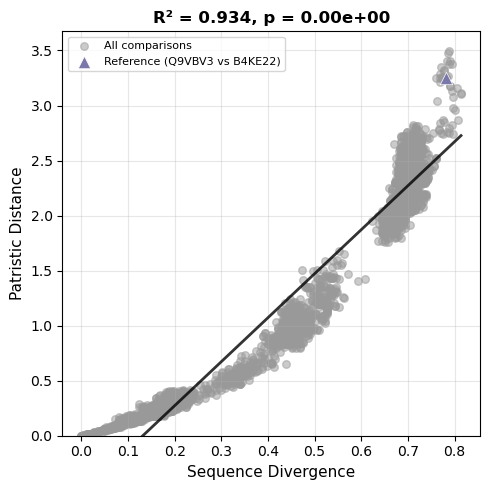

✓ Saved: output_plots/correlation_sequence_divergence_vs_tm_score.png
✓ Saved: output_plots/correlation_sequence_divergence_vs_tm_score.svg


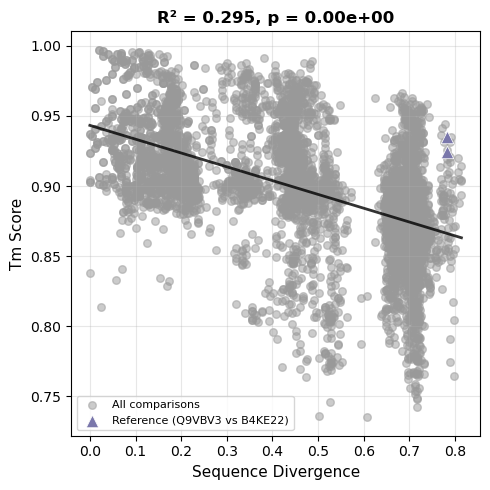

✓ Saved: output_plots/correlation_patristic_distance_vs_tm_score.png
✓ Saved: output_plots/correlation_patristic_distance_vs_tm_score.svg


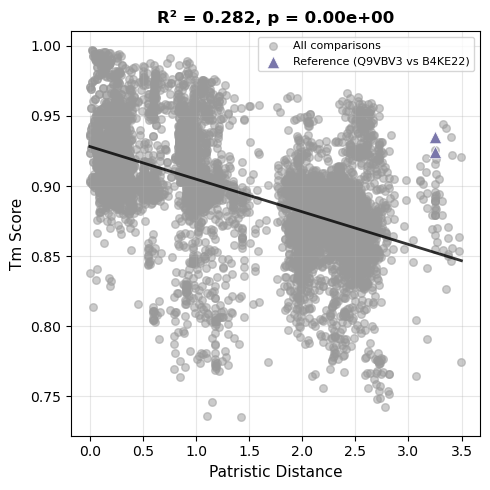


Correlation Matrix (Pearson R):


,sequence_divergence,patristic_distance,tm_score
sequence_divergence,1.000000,0.966529,-0.543223
patristic_distance,0.966529,1.000000,-0.530584
tm_score,-0.543223,-0.530584,1.000000


In [47]:
# Create correlation plots
plot_correlation_matrix(metrics_df)

## Step 16: Visualize Correlations - Separating Within And Between Clusters

In [48]:
def plot_correlation_matrix_col(df):
    """
    Create pairwise correlation scatter plots coloured by cluster_key,
    with per-cluster regression lines.

    Parameters
    ----------
    df : pd.DataFrame
        Output of integrate_all_metrics() with cluster annotations.

    Returns
    -------
    pd.DataFrame
        R² and p-value summary per cluster and metric pair.
    """
    CLUSTER_KEY_COLORS = {
        "Cluster_1_Cluster_1": "#73b5e3",
        "Cluster_2_Cluster_2": "#F28360",
        "Cluster_3_Cluster_3": "#3B9886",
    }
    CROSS_COLOR = "#555555"  # grey — between-cluster comparisons
    REF_COLOR = "#7A77AB"  # purple — reference pair overlay

    METRICS = ["sequence_divergence", "patristic_distance", "tm_score"]
    COMPARISONS = [
        ("sequence_divergence", "patristic_distance"),
        ("sequence_divergence", "tm_score"),
        ("patristic_distance", "tm_score"),
    ]
    # Symmetric metric pairs — deduplicate to one direction only
    SYMMETRIC_COMPARISONS = {("sequence_divergence", "patristic_distance")}

    def get_color(ck):
        if ck in CLUSTER_KEY_COLORS:
            return CLUSTER_KEY_COLORS[ck]
        if "Cluster_4" in ck:
            return "#C85152"
        return CROSS_COLOR

    def darken(hex_color, factor=0.6):
        r, g, b = (int(hex_color.lstrip("#")[i : i + 2], 16) for i in (0, 2, 4))
        return f"#{int(r*factor):02x}{int(g*factor):02x}{int(b*factor):02x}"

    def label(v):
        return v.replace("_", " ").title()

    data = (
        df[METRICS + ["cluster_key", "protein1", "protein2"]].copy().dropna(subset=["cluster_key"])
    )
    dedup = data[data["protein1"] < data["protein2"]]
    cluster_keys = sorted(data["cluster_key"].unique())

    ref_mask = (
        data["protein1"].str.startswith("Q9VBV3") & data["protein2"].str.startswith("B4KE22")
    ) | (data["protein1"].str.startswith("B4KE22") & data["protein2"].str.startswith("Q9VBV3"))
    ref_data = data[ref_mask]
    ref_data_dedup = dedup[ref_mask.reindex(dedup.index, fill_value=False)]

    ordered_keys = sorted(cluster_keys, key=lambda ck: get_color(ck) != CROSS_COLOR)

    for x_var, y_var in COMPARISONS:
        is_symmetric = (x_var, y_var) in SYMMETRIC_COMPARISONS
        src = dedup if is_symmetric else data
        src_ref = ref_data_dedup if is_symmetric else ref_data

        fig, ax = plt.subplots(figsize=(6, 6))
        fits = []

        for ck in ordered_keys:
            subset = src[src["cluster_key"] == ck]
            color = get_color(ck)
            ax.scatter(
                subset[x_var],
                subset[y_var],
                alpha=0.5,
                s=30,
                color=color,
                zorder=1 if color == CROSS_COLOR else 2,
                label=ck if color != CROSS_COLOR else None,
            )
            if len(subset) >= 3:
                fits.append((subset[x_var], subset[y_var], color))

        for x_data, y_data, color in fits:
            x_line = np.linspace(x_data.min(), x_data.max(), 100)
            ax.plot(
                x_line,
                np.poly1d(np.polyfit(x_data, y_data, 1))(x_line),
                "-",
                color=darken(color),
                linewidth=2,
                zorder=10,
            )

        ax.scatter(
            src_ref[x_var],
            src_ref[y_var],
            color=REF_COLOR,
            marker="^",
            s=80,
            zorder=15,
            edgecolors="white",
            linewidths=0.5,
            label="Reference (Q9VBV3 vs B4KE22)",
        )

        if y_var == "patristic_distance":
            ax.set_ylim(max(0, ax.get_ylim()[0]), ax.get_ylim()[1])

        ax.set_xlabel(label(x_var), fontsize=11)
        ax.set_ylabel(label(y_var), fontsize=11)
        ax.set_title(f"{label(x_var)} vs {label(y_var)}", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, frameon=True)
        plt.tight_layout()

        for ext, kwargs in [("png", {"dpi": 300}), ("svg", {"format": "svg"})]:
            fname = f"output_plots/correlation2_{x_var}_vs_{y_var}.{ext}"
            plt.savefig(fname, bbox_inches="tight", **kwargs)
            print(f"✓ Saved: {fname}")

        plt.show()

    # --- R² summary table ---
    all_rows = []
    for ck in cluster_keys:
        subset = data[data["cluster_key"] == ck]
        row = {"cluster_key": ck, "n": len(subset)}
        for x_var, y_var in COMPARISONS:
            r2_col = f"R²_{x_var}_vs_{y_var}"
            p_col = r2_col.replace("R²", "p")
            if len(subset) >= 3:
                r, p = pearsonr(subset[x_var], subset[y_var])
                row[r2_col] = round(r**2, 4)
                row[p_col] = round(p, 6)
            else:
                row[r2_col] = row[p_col] = None
        all_rows.append(row)

    stats_df = pd.DataFrame(all_rows)
    display(stats_df)
    return stats_df

In our plot we will now colour within group comparisons e.g. where both proteins are in cluster 1 (blue), both in cluster 2(orange), both in cluster 3 (green), and then any comparison between cluster 4 (REF) is in red. All other comparisons are grey

✓ Saved: output_plots/correlation2_sequence_divergence_vs_patristic_distance.png
✓ Saved: output_plots/correlation2_sequence_divergence_vs_patristic_distance.svg


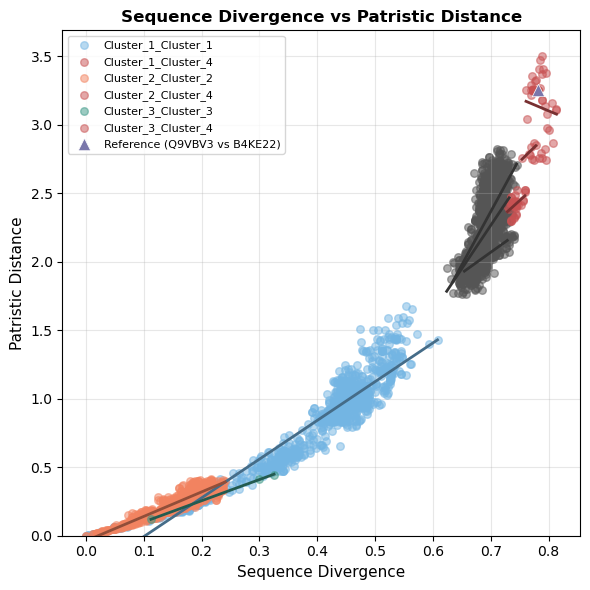

✓ Saved: output_plots/correlation2_sequence_divergence_vs_tm_score.png
✓ Saved: output_plots/correlation2_sequence_divergence_vs_tm_score.svg


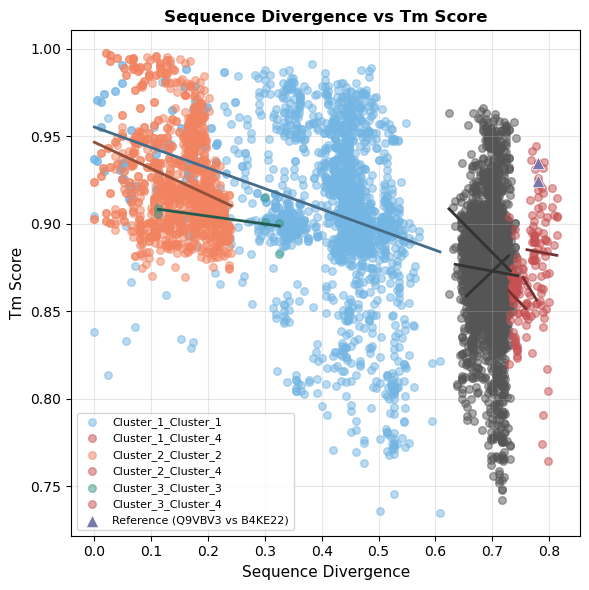

✓ Saved: output_plots/correlation2_patristic_distance_vs_tm_score.png
✓ Saved: output_plots/correlation2_patristic_distance_vs_tm_score.svg


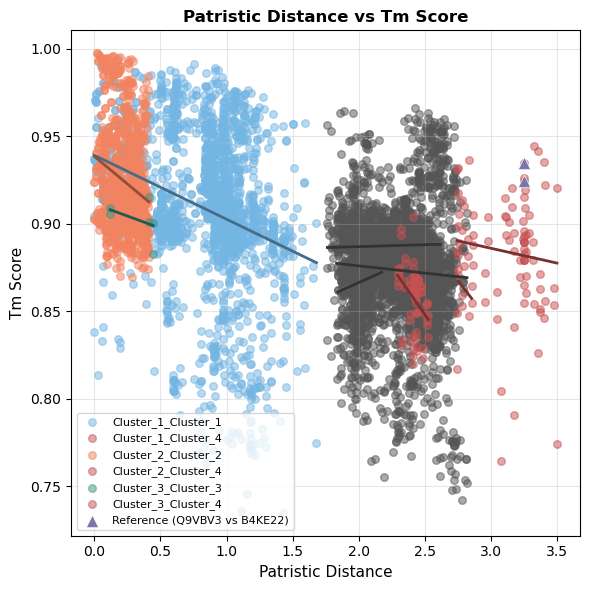

,cluster_key,n,R²_sequence_divergence_vs_patristic_distance,p_sequence_divergence_vs_patristic_distance,R²_sequence_divergence_vs_tm_score,p_sequence_divergence_vs_tm_score,R²_patristic_distance_vs_tm_score,p_patristic_distance_vs_tm_score
0,Cluster_1_Cluster_1,1892,0.8914,0.000000,0.0952,0.000000,0.0827,0.000000
1,Cluster_1_Cluster_2,3080,0.4554,0.000000,0.0015,0.033046,0.0038,0.000653
2,Cluster_1_Cluster_3,264,0.3068,0.000000,0.0405,0.001008,0.0002,0.808047
3,Cluster_1_Cluster_4,88,0.0105,0.342918,0.0005,0.831524,0.0121,0.308143
4,Cluster_2_Cluster_2,1190,0.8634,0.000000,0.0792,0.000000,0.0513,0.000000
5,Cluster_2_Cluster_3,210,0.3886,0.000000,0.0664,0.000160,0.0187,0.048000
6,Cluster_2_Cluster_4,70,0.2388,0.000018,0.0222,0.218624,0.1432,0.001238
7,Cluster_3_Cluster_3,6,0.9993,0.000000,0.1789,0.403331,0.1652,0.423961
8,Cluster_3_Cluster_4,6,0.9440,0.001197,0.4570,0.140451,0.2688,0.292021


,cluster_key,n,R²_sequence_divergence_vs_patristic_distance,p_sequence_divergence_vs_patristic_distance,R²_sequence_divergence_vs_tm_score,p_sequence_divergence_vs_tm_score,R²_patristic_distance_vs_tm_score,p_patristic_distance_vs_tm_score
0,Cluster_1_Cluster_1,1892,0.8914,0.000000,0.0952,0.000000,0.0827,0.000000
1,Cluster_1_Cluster_2,3080,0.4554,0.000000,0.0015,0.033046,0.0038,0.000653
2,Cluster_1_Cluster_3,264,0.3068,0.000000,0.0405,0.001008,0.0002,0.808047
3,Cluster_1_Cluster_4,88,0.0105,0.342918,0.0005,0.831524,0.0121,0.308143
4,Cluster_2_Cluster_2,1190,0.8634,0.000000,0.0792,0.000000,0.0513,0.000000
5,Cluster_2_Cluster_3,210,0.3886,0.000000,0.0664,0.000160,0.0187,0.048000
6,Cluster_2_Cluster_4,70,0.2388,0.000018,0.0222,0.218624,0.1432,0.001238
7,Cluster_3_Cluster_3,6,0.9993,0.000000,0.1789,0.403331,0.1652,0.423961
8,Cluster_3_Cluster_4,6,0.9440,0.001197,0.4570,0.140451,0.2688,0.292021


In [49]:
# Create correlation plots
plot_correlation_matrix_col(metrics_df)

Now let's plot some boxplots to show us how the different clusters vary from one another

✓ Saved: output_plots/boxplots_by_cluster.png
✓ Saved: output_plots/boxplots_by_cluster.svg


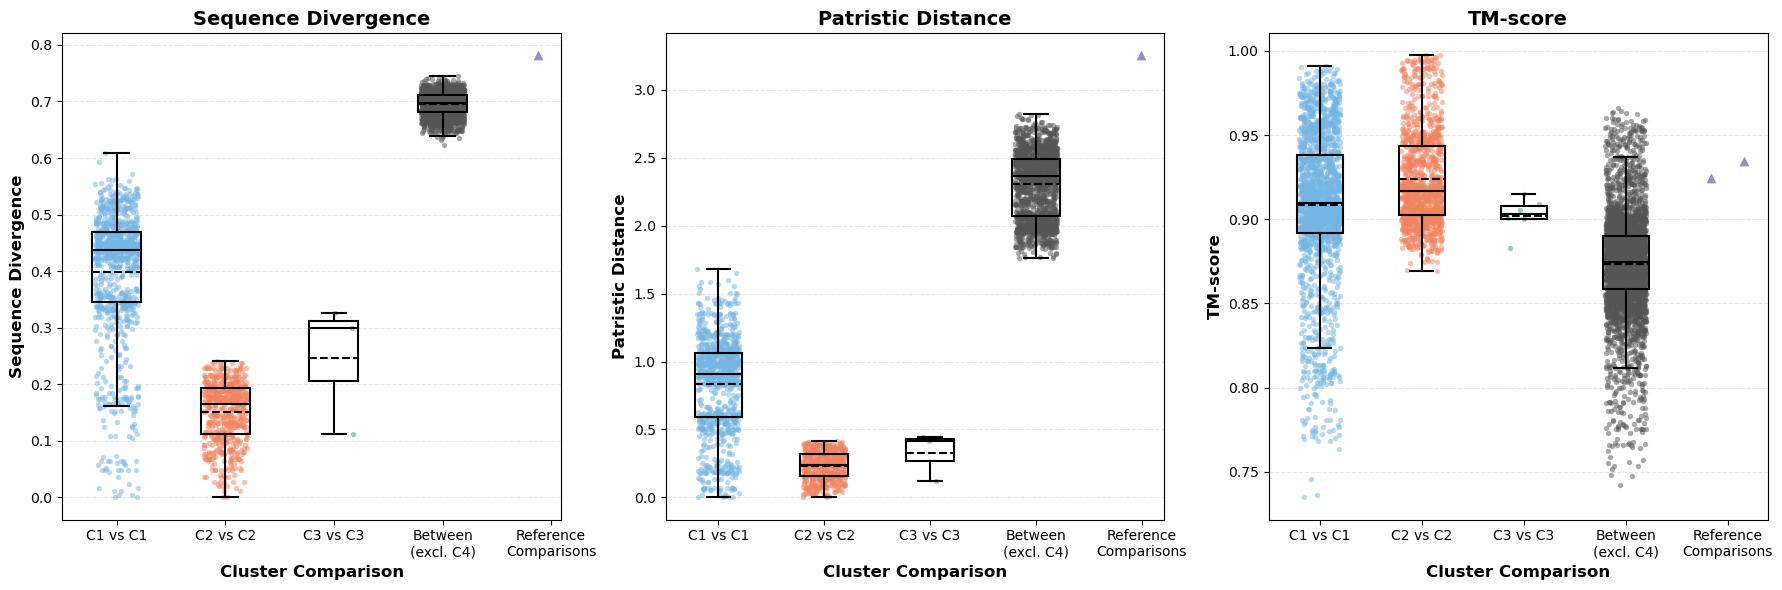

Summary Statistics by Cluster Comparison

Sequence Divergence:
  C1 vs C1:      mean=0.3982, median=0.4374, n=946
  C2 vs C2:      mean=0.1503, median=0.1647, n=595
  C3 vs C3:      mean=0.2459, median=0.3000, n=3
  Between:       mean=0.6953, median=0.6980, n=1777
  Reference:     mean=0.7814, median=0.7814, n=1

Patristic Distance:
  C1 vs C1:      mean=0.8364, median=0.9091, n=946
  C2 vs C2:      mean=0.2308, median=0.2421, n=595
  C3 vs C3:      mean=0.3261, median=0.4147, n=3
  Between:       mean=2.3101, median=2.3681, n=1777
  Reference:     mean=3.2530, median=3.2530, n=1

TM-score:
  C1 vs C1:      mean=0.9085, median=0.9099, n=1892
  C2 vs C2:      mean=0.9239, median=0.9171, n=1190
  C3 vs C3:      mean=0.9022, median=0.9032, n=6
  Between:       mean=0.8737, median=0.8749, n=3554
  Reference:     mean=0.9295, median=0.9295, n=2


In [51]:
def jitter_scatter(ax, pos, data, color, marker="o", s=15, alpha=0.5):
    """
    Plot jittered points at a given x position on an axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    pos : float
        Centre x position.
    data : array-like
        Y values to plot.
    color : str
        Point color.
    marker : str
        Marker style.
    s : float
        Marker size.
    alpha : float
        Marker opacity.
    """
    j = np.random.uniform(-0.2, 0.2, size=len(data))
    ax.scatter(pos + j, data, alpha=alpha, s=s, color=color, marker=marker, zorder=3, linewidths=0)


def plot_cluster_boxplots(metrics_df):
    """
    Boxplots with jittered points for each metric, grouped by cluster comparison.

    Parameters
    ----------
    metrics_df : pd.DataFrame
        Output of integrate_all_metrics() with cluster annotations.
    """
    METRICS = ["sequence_divergence", "patristic_distance", "tm_score"]
    METRIC_LABELS = ["Sequence Divergence", "Patristic Distance", "TM-score"]

    WITHIN_KEYS = ["Cluster_1_Cluster_1", "Cluster_2_Cluster_2", "Cluster_3_Cluster_3"]
    WITHIN_COLORS = ["#73b5e3", "#F28360", "#3B9886"]
    WITHIN_LABELS = ["C1 vs C1", "C2 vs C2", "C3 vs C3"]

    BETWEEN_COLOR = "#555555"
    REF_COLOR = "#7A77AB"

    BOX_COLORS = WITHIN_COLORS + [BETWEEN_COLOR]
    BOX_LABELS = WITHIN_LABELS + ["Between\n(excl. C4)", "Reference\nComparisons"]

    dedup_df = metrics_df[metrics_df["protein1"] < metrics_df["protein2"]].copy()

    between_keys = [
        ck
        for ck in metrics_df["cluster_key"].dropna().unique()
        if ck not in WITHIN_KEYS and "Cluster_4" not in ck
    ]

    def ref_mask(df):
        return (
            df["protein1"].str.startswith("Q9VBV3") & df["protein2"].str.startswith("B4KE22")
        ) | (df["protein1"].str.startswith("B4KE22") & df["protein2"].str.startswith("Q9VBV3"))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, metric, label in zip(axes, METRICS, METRIC_LABELS, strict=False):
        src = metrics_df if metric == "tm_score" else dedup_df

        groups = [src[src["cluster_key"] == ck][metric].dropna() for ck in WITHIN_KEYS]
        groups.append(src[src["cluster_key"].isin(between_keys)][metric].dropna())
        ref = src[ref_mask(src)][metric].dropna()

        bp = ax.boxplot(
            groups,
            positions=range(1, 5),
            tick_labels=BOX_LABELS[:4],
            patch_artist=True,
            showmeans=True,
            meanline=True,
            zorder=2,
        )

        for patch in bp["boxes"]:
            patch.set(facecolor="none", edgecolor="black", linewidth=1.5, zorder=5)
        for el in ["medians", "means", "whiskers", "caps", "fliers"]:
            for line in bp[el]:
                line.set_visible(False)

        for pos, (subset, color) in enumerate(zip(groups, BOX_COLORS, strict=False), start=1):
            jitter_scatter(ax, pos, subset, color)

        for el in ["medians", "means", "whiskers", "caps"]:
            for line in bp[el]:
                line.set(color="black", linewidth=1.5, zorder=5, visible=True)

        jitter_scatter(ax, 5, ref, REF_COLOR, marker="^", s=50, alpha=0.8)

        ax.set_xticks(range(1, 6))
        ax.set_xticklabels(BOX_LABELS)
        ax.set_xlabel("Cluster Comparison", fontsize=12, fontweight="bold")
        ax.set_ylabel(label, fontsize=12, fontweight="bold")
        ax.set_title(label, fontsize=14, fontweight="bold")
        ax.grid(True, alpha=0.3, linestyle="--", axis="y")

    plt.tight_layout()
    for ext, kwargs in [("png", {"dpi": 300}), ("svg", {"format": "svg"})]:
        fname = f"output_plots/boxplots_by_cluster.{ext}"
        plt.savefig(fname, bbox_inches="tight", **kwargs)
        print(f"✓ Saved: {fname}")
    plt.show()

    # --- Summary statistics ---
    print("Summary Statistics by Cluster Comparison\n" + "=" * 50)
    for metric, label in zip(METRICS, METRIC_LABELS, strict=False):
        src = metrics_df if metric == "tm_score" else dedup_df
        ref = src[ref_mask(src)][metric].dropna()
        print(f"\n{label}:")
        for ck, lbl in zip(WITHIN_KEYS, WITHIN_LABELS, strict=False):
            s = src[src["cluster_key"] == ck][metric].dropna()
            print(f"  {lbl+':':14s} mean={s.mean():.4f}, median={s.median():.4f}, n={len(s)}")
        b = src[src["cluster_key"].isin(between_keys)][metric].dropna()
        print(f"  {'Between:':14s} mean={b.mean():.4f}, median={b.median():.4f}, n={len(b)}")
        stats = f"mean={ref.mean():.4f}, median={ref.median():.4f}, n={len(ref)}"
        print(f"  {'Reference:':14s} {stats}")


plot_cluster_boxplots(metrics_df)

- Bottom and top of the box = IQR
- Orange/solid horizontal line = the median
- Dashed horizontal line = the mean
- Whiskers — extend to 1.5× IQR beyond box 

## Step 17: Compare Split Domains to Single-Domain Proteins

Numerous species have two different proteins in our dataset - this raises the question as to whether the observed sequence diversity or structural diversity are more or less substantial where we have split multiple domains from the same sequence
- Category 1: Same species comparisons where both proteins are single domains (part1_of1)
- Category 2: Within the same protein, comparing part1_of2 vs part2_of2 (dimer domains)
- Category 3: Within the same protein, all pairwise comparisons between the three parts of trimers

✓ Saved: output_plots/boxplots_structural_classes.png
✓ Saved: output_plots/boxplots_structural_classes.svg


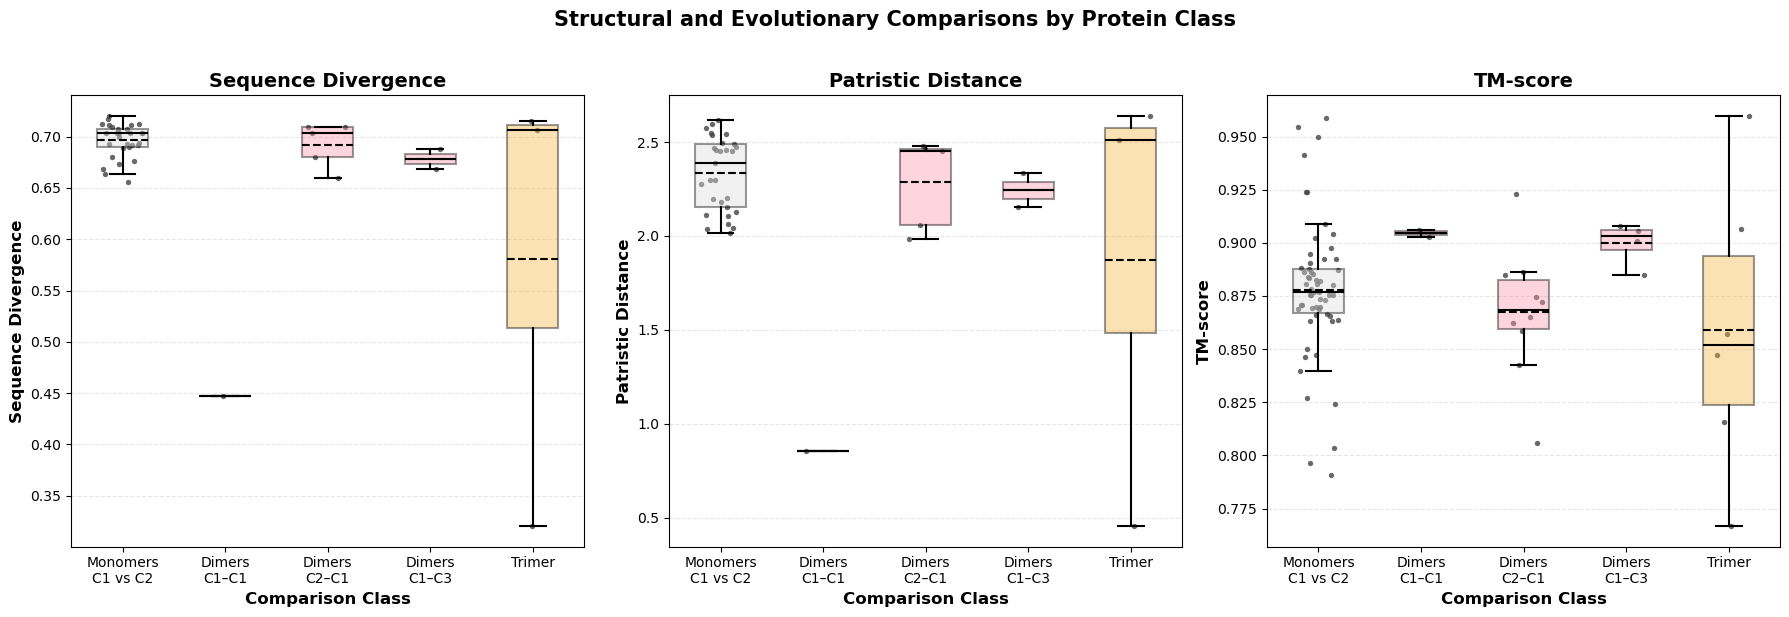

Summary Statistics

Sequence Divergence:
  Monomers C1 vs C2:     mean=0.6962, median=0.7037, n=29
  Dimers C1–C1:          mean=0.4472, median=0.4472, n=1
  Dimers C2–C1:          mean=0.6922, median=0.7037, n=5
  Dimers C1–C3:          mean=0.6781, median=0.6781, n=2
  Trimer:                mean=0.5807, median=0.7067, n=3

Patristic Distance:
  Monomers C1 vs C2:     mean=2.3333, median=2.3894, n=29
  Dimers C1–C1:          mean=0.8522, median=0.8522, n=1
  Dimers C2–C1:          mean=2.2884, median=2.4503, n=5
  Dimers C1–C3:          mean=2.2435, median=2.2435, n=2
  Trimer:                mean=1.8695, median=2.5138, n=3

TM-score:
  Monomers C1 vs C2:     mean=0.8778, median=0.8769, n=58
  Dimers C1–C1:          mean=0.9044, median=0.9044, n=2
  Dimers C2–C1:          mean=0.8675, median=0.8686, n=10
  Dimers C1–C3:          mean=0.8998, median=0.9032, n=4
  Trimer:                mean=0.8588, median=0.8521, n=6

Matching rows per box

Box 1 — Monomers C1 vs C2 (n=58):


,protein1,protein2,protein1_cluster,protein2_cluster,cluster_key,sequence_divergence,patristic_distance,tm_score
747,P005067004171_Drosophila_biarmipes_part1_of1,P005067004172_Drosophila_biarmipes_part1_of1,Cluster_2,Cluster_1,Cluster_1_Cluster_2,0.720165,2.546740,0.87001
829,P005067004172_Drosophila_biarmipes_part1_of1,P005067004171_Drosophila_biarmipes_part1_of1,Cluster_1,Cluster_2,Cluster_1_Cluster_2,0.720165,2.546740,0.87672
1079,P005070006661_Drosophila_bunnanda_part1_of1,P005070006662_Drosophila_bunnanda_part1_of1,Cluster_1,Cluster_2,Cluster_1_Cluster_2,0.688889,2.543200,0.95458
1161,P005070006662_Drosophila_bunnanda_part1_of1,P005070006661_Drosophila_bunnanda_part1_of1,Cluster_2,Cluster_1,Cluster_1_Cluster_2,0.688889,2.543200,0.86615
1245,P005071004180_Drosophila_busckii_part1_of1,P005071007432_Drosophila_busckii_part1_of1,Cluster_2,Cluster_1,Cluster_1_Cluster_2,0.693333,2.038388,0.92389
1327,P005071007432_Drosophila_busckii_part1_of1,P005071004180_Drosophila_busckii_part1_of1,Cluster_1,Cluster_2,Cluster_1_Cluster_2,0.693333,2.038388,0.92389
1411,P005072008715_Drosophila_elegans_part1_of1,P005072008716_Drosophila_elegans_part1_of1,Cluster_2,Cluster_1,Cluster_1_Cluster_2,0.703704,2.459951,0.87531
1493,P005072008716_Drosophila_elegans_part1_of1,P005072008715_Drosophila_elegans_part1_of1,Cluster_1,Cluster_2,Cluster_1_Cluster_2,0.703704,2.459951,0.88210
1660,P005074010565_Drosophila_eugracilis_part1_of1,P005074010571_Drosophila_eugracilis_part1_of1,Cluster_1,Cluster_2,Cluster_1_Cluster_2,0.707819,2.472291,0.89487
1742,P005074010571_Drosophila_eugracilis_part1_of1,P005074010565_Drosophila_eugracilis_part1_of1,Cluster_2,Cluster_1,Cluster_1_Cluster_2,0.707819,2.472291,0.88795


  ✓ Saved to output_files/box1_Monomers_C1_vs_C2.csv

Box 2 — Dimers C1–C1 (n=2):


,protein1,protein2,protein1_cluster,protein2_cluster,cluster_key,sequence_divergence,patristic_distance,tm_score
83,P005064008787_Drosophila_albomicans_part1_of2,P005064008787_Drosophila_albomicans_part2_of2,Cluster_1,Cluster_1,Cluster_1_Cluster_1,0.447154,0.852182,0.90267
165,P005064008787_Drosophila_albomicans_part2_of2,P005064008787_Drosophila_albomicans_part1_of2,Cluster_1,Cluster_1,Cluster_1_Cluster_1,0.447154,0.852182,0.90621


  ✓ Saved to output_files/box2_Dimers_C1–C1.csv

Box 3 — Dimers C2–C1 (n=10):


...

  ✓ Saved to output_files/box3_Dimers_C2–C1.csv

Box 4 — Dimers C1–C3 (n=4):


,protein1,protein2,protein1_cluster,protein2_cluster,cluster_key,sequence_divergence,patristic_distance,tm_score
332,P005065001328_Drosophila_ananassae_part1_of2,P005065001328_Drosophila_ananassae_part2_of2,Cluster_1,Cluster_3,Cluster_1_Cluster_3,0.688259,2.334935,0.90565
414,P005065001328_Drosophila_ananassae_part2_of2,P005065001328_Drosophila_ananassae_part1_of2,Cluster_3,Cluster_1,Cluster_1_Cluster_3,0.688259,2.334935,0.88501
5561,P005097008429_Drosophila_subobscura_part1_of2,P005097008429_Drosophila_subobscura_part2_of2,Cluster_1,Cluster_3,Cluster_1_Cluster_3,0.668033,2.152064,0.90776
5643,P005097008429_Drosophila_subobscura_part2_of2,P005097008429_Drosophila_subobscura_part1_of2,Cluster_3,Cluster_1,Cluster_1_Cluster_3,0.668033,2.152064,0.90076


  ✓ Saved to output_files/box4_Dimers_C1–C3.csv

Box 5 — Trimer (n=6):


,protein1,protein2,protein1_cluster,protein2_cluster,cluster_key,sequence_divergence,patristic_distance,tm_score
3071,P005081003743_Drosophila_kikkawai_part1_of3,P005081003743_Drosophila_kikkawai_part2_of3,Cluster_2,Cluster_1,Cluster_1_Cluster_2,0.706731,2.640089,0.76677
3072,P005081003743_Drosophila_kikkawai_part1_of3,P005081003743_Drosophila_kikkawai_part3_of3,Cluster_2,Cluster_1,Cluster_1_Cluster_2,0.714876,2.513799,0.84727
3153,P005081003743_Drosophila_kikkawai_part2_of3,P005081003743_Drosophila_kikkawai_part1_of3,Cluster_1,Cluster_2,Cluster_1_Cluster_2,0.706731,2.640089,0.90630
3154,P005081003743_Drosophila_kikkawai_part2_of3,P005081003743_Drosophila_kikkawai_part3_of3,Cluster_1,Cluster_1,Cluster_1_Cluster_1,0.320574,0.454679,0.95973
3235,P005081003743_Drosophila_kikkawai_part3_of3,P005081003743_Drosophila_kikkawai_part1_of3,Cluster_1,Cluster_2,Cluster_1_Cluster_2,0.714876,2.513799,0.85695
3236,P005081003743_Drosophila_kikkawai_part3_of3,P005081003743_Drosophila_kikkawai_part2_of3,Cluster_1,Cluster_1,Cluster_1_Cluster_1,0.320574,0.454679,0.81573


  ✓ Saved to output_files/box5_Trimer.csv


In [52]:
def plot_structural_classes(metrics_df):
    """
    Boxplots comparing sequence divergence, patristic distance, and TM-score
    across protein domain classes (monomers, dimers, trimers).

    Parameters
    ----------
    metrics_df : pd.DataFrame
        Output of integrate_all_metrics() with cluster annotations.
    """
    METRICS = ["sequence_divergence", "patristic_distance", "tm_score"]
    METRIC_LABELS = ["Sequence Divergence", "Patristic Distance", "TM-score"]

    BOX_FILL_COLORS = ["#dddddd", "#F898AE", "#F898AE", "#F898AE", "#F7B846"]
    POINT_COLOR = "#444444"

    BOX_LABELS = [
        "Monomers\nC1 vs C2",
        "Dimers\nC1–C1",
        "Dimers\nC2–C1",
        "Dimers\nC1–C3",
        "Trimer",
    ]
    OUTPUT_COLS = [
        "protein1",
        "protein2",
        "protein1_cluster",
        "protein2_cluster",
        "cluster_key",
        "sequence_divergence",
        "patristic_distance",
        "tm_score",
    ]

    # --- Parse protein IDs ---
    p1 = metrics_df["protein1"].apply(parse_protein)
    p2 = metrics_df["protein2"].apply(parse_protein)

    same_species = metrics_df.apply(
        lambda r: p1[r.name]["species"] == p2[r.name]["species"], axis=1
    )
    same_base = metrics_df.apply(lambda r: p1[r.name]["base_id"] == p2[r.name]["base_id"], axis=1)
    neither_ref = metrics_df.apply(
        lambda r: not p1[r.name]["is_ref"] and not p2[r.name]["is_ref"], axis=1
    )
    p1_total = p1.apply(lambda x: x["total_parts"])
    p2_total = p2.apply(lambda x: x["total_parts"])

    # --- Box masks ---
    box_masks = [
        # Box 1: monomers, C1 vs C2
        same_species
        & neither_ref
        & (p1_total == 1)
        & (p2_total == 1)
        & (metrics_df["cluster_key"] == "Cluster_1_Cluster_2"),
        # Box 2: dimers, same base, both C1
        same_species
        & same_base
        & neither_ref
        & (p1_total == 2)
        & (p2_total == 2)
        & (metrics_df["protein1_cluster"] == "Cluster_1")
        & (metrics_df["protein2_cluster"] == "Cluster_1"),
        # Box 3: dimers, same base, C1 vs C2
        same_species
        & same_base
        & neither_ref
        & (p1_total == 2)
        & (p2_total == 2)
        & (metrics_df["cluster_key"] == "Cluster_1_Cluster_2"),
        # Box 4: dimers, same base, C1 vs C3
        same_species
        & same_base
        & neither_ref
        & (p1_total == 2)
        & (p2_total == 2)
        & (metrics_df["cluster_key"] == "Cluster_1_Cluster_3"),
        # Box 5: trimers, same base, any two parts
        same_species & same_base & neither_ref & (p1_total == 3) & (p2_total == 3),
    ]

    dedup_df = metrics_df[metrics_df["protein1"] < metrics_df["protein2"]].copy()

    def get_groups(src):
        return [
            src[mask.reindex(src.index, fill_value=False)][metric].dropna() for mask in box_masks
        ]

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "Structural and Evolutionary Comparisons by Protein Class",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )

    for ax, metric, label in zip(axes, METRICS, METRIC_LABELS, strict=False):
        src = metrics_df if metric == "tm_score" else dedup_df
        groups = get_groups(src)

        bp = ax.boxplot(
            groups,
            positions=range(1, 6),
            tick_labels=BOX_LABELS,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            zorder=2,
        )

        for patch, fill in zip(bp["boxes"], BOX_FILL_COLORS, strict=False):
            patch.set(facecolor=fill, alpha=0.4, edgecolor="black", linewidth=1.5, zorder=5)

        for el in ["medians", "means", "whiskers", "caps", "fliers"]:
            for line in bp[el]:
                line.set_visible(False)

        for pos, subset in enumerate(groups, start=1):
            jitter_scatter(ax, pos, subset, POINT_COLOR, alpha=0.8)

        for el in ["medians", "means", "whiskers", "caps"]:
            for line in bp[el]:
                line.set(color="black", linewidth=1.5, zorder=5, visible=True)

        ax.set_xlabel("Comparison Class", fontsize=12, fontweight="bold")
        ax.set_ylabel(label, fontsize=12, fontweight="bold")
        ax.set_title(label, fontsize=14, fontweight="bold")
        ax.grid(True, alpha=0.3, linestyle="--", axis="y")

    plt.tight_layout()
    for ext, kwargs in [("png", {"dpi": 300}), ("svg", {"format": "svg"})]:
        fname = f"output_plots/boxplots_structural_classes.{ext}"
        plt.savefig(fname, bbox_inches="tight", **kwargs)
        print(f"✓ Saved: {fname}")
    plt.show()

    # --- Summary statistics ---
    print("Summary Statistics\n" + "=" * 50)
    for metric, label in zip(METRICS, METRIC_LABELS, strict=False):
        src = metrics_df if metric == "tm_score" else dedup_df
        print(f"\n{label}:")
        for mask, lbl in zip(box_masks, BOX_LABELS, strict=False):
            subset = src[mask.reindex(src.index, fill_value=False)][metric].dropna()
            lbl_clean = lbl.replace("\n", " ")
            print(
                f"  {lbl_clean+':':22s} mean={subset.mean():.4f}, "
                f"median={subset.median():.4f}, n={len(subset)}"
            )

    # --- Per-box detail tables ---
    print("\nMatching rows per box\n" + "=" * 50)
    for i, (mask, lbl) in enumerate(zip(box_masks, BOX_LABELS, strict=False), start=1):
        subset = metrics_df[mask]
        lbl_clean = lbl.replace("\n", " ")
        print(f"\nBox {i} — {lbl_clean} (n={len(subset)}):")
        display(subset[OUTPUT_COLS])
        fname = f'output_files/box{i}_{lbl_clean.replace(" ", "_").replace("/", "-")}.csv'
        subset[OUTPUT_COLS].to_csv(fname, index=False)
        print(f"  ✓ Saved to {fname}")


plot_structural_classes(metrics_df)

## Step 18: Extract Drosophila melanogaster and Drosophila mojavensis example

In [53]:
# --- Add species columns using existing parse_protein helper ---
metrics_df["species1"] = metrics_df["protein1"].apply(lambda x: parse_protein(x)["species"])
metrics_df["species2"] = metrics_df["protein2"].apply(lambda x: parse_protein(x)["species"])

# --- Filter for melanogaster–mojavensis comparisons (both directions) ---
mel_moj_df = metrics_df[
    (
        metrics_df["protein1"].str.contains("melanogaster", case=False)
        & metrics_df["protein2"].str.contains("mojavensis", case=False)
    )
    | (
        metrics_df["protein1"].str.contains("mojavensis", case=False)
        & metrics_df["protein2"].str.contains("melanogaster", case=False)
    )
].copy()

print(
    f"Found {len(mel_moj_df)} melanogaster–mojavensis comparisons "
    f"(out of {len(metrics_df)} total)"
)

# --- Summary statistics ---
if not mel_moj_df.empty:
    print(f"\n{'='*60}\nSummary Statistics:\n{'='*60}")
    _print_stats("TM-score", mel_moj_df["tm_score"])

    mel_as_p1 = (mel_moj_df["species1"] == "Drosophila_melanogaster").sum()
    moj_as_p1 = (mel_moj_df["species1"] == "Drosophila_mojavensis").sum()
    ref_rows = (
        mel_moj_df["protein1"].str.contains("REF") | mel_moj_df["protein2"].str.contains("REF")
    ).sum()
    print("\nOrientation:")
    print(f"  D. melanogaster as protein1:   {mel_as_p1}")
    print(f"  D. mojavensis as protein1:     {moj_as_p1}")
    print(f"  Rows involving a REF sequence: {ref_rows}")

print("\nComparisons:")
display(mel_moj_df.head(20))

output_file = "output_files/melanogaster_mojavensis_comparisons.csv"
mel_moj_df.to_csv(output_file, index=False)
print(f"\n✓ Saved {len(mel_moj_df)} comparisons to: {output_file}")

Found 18 melanogaster–mojavensis comparisons (out of 6806 total)

Summary Statistics:

TM-score statistics:
  Mean:    0.884
  Median:  0.881
  Min:     0.845
  Max:     0.935

Orientation:
  D. melanogaster as protein1:   6
  D. mojavensis as protein1:     6
  Rows involving a REF sequence: 10

Comparisons:


,protein1,protein2,tm_score,sequence_divergence,patristic_distance,protein1_cluster,protein2_cluster,cluster_key,species1,species2
42,B4KE22_Drosophila_mojavensisREF_part1_of1,P005083008909_Drosophila_melanogaster_part1_of1,0.86287,0.739837,2.409154,Cluster_4,Cluster_2,Cluster_2_Cluster_4,Drosophila_mojavensisREF,Drosophila_melanogaster
43,B4KE22_Drosophila_mojavensisREF_part1_of1,P005083008910_Drosophila_melanogaster_part1_of1,0.88535,0.781377,3.252951,Cluster_4,Cluster_1,Cluster_1_Cluster_4,Drosophila_mojavensisREF,Drosophila_melanogaster
81,B4KE22_Drosophila_mojavensisREF_part1_of1,Q9VBV3_Drosophila_melanogasterREF_part1_of1,0.92424,0.781377,3.252951,Cluster_4,Cluster_1,Cluster_1_Cluster_4,Drosophila_mojavensisREF,Drosophila_melanogasterREF
3526,P005083008909_Drosophila_melanogaster_part1_of1,B4KE22_Drosophila_mojavensisREF_part1_of1,0.86612,0.739837,2.409154,Cluster_2,Cluster_4,Cluster_2_Cluster_4,Drosophila_melanogaster,Drosophila_mojavensisREF
3572,P005083008909_Drosophila_melanogaster_part1_of1,P005085005288_Drosophila_mojavensis_part1_of1,0.90482,0.212851,0.376535,Cluster_2,Cluster_2,Cluster_2_Cluster_2,Drosophila_melanogaster,Drosophila_mojavensis
3573,P005083008909_Drosophila_melanogaster_part1_of1,P005085005289_Drosophila_mojavensis_part1_of1,0.84586,0.666667,1.997572,Cluster_2,Cluster_1,Cluster_1_Cluster_2,Drosophila_melanogaster,Drosophila_mojavensis
3608,P005083008910_Drosophila_melanogaster_part1_of1,B4KE22_Drosophila_mojavensisREF_part1_of1,0.89555,0.781377,3.252951,Cluster_1,Cluster_4,Cluster_1_Cluster_4,Drosophila_melanogaster,Drosophila_mojavensisREF
3654,P005083008910_Drosophila_melanogaster_part1_of1,P005085005288_Drosophila_mojavensis_part1_of1,0.87096,0.690083,2.573084,Cluster_1,Cluster_2,Cluster_1_Cluster_2,Drosophila_melanogaster,Drosophila_mojavensis
3655,P005083008910_Drosophila_melanogaster_part1_of1,P005085005289_Drosophila_mojavensis_part1_of1,0.87278,0.468880,1.022186,Cluster_1,Cluster_1,Cluster_1_Cluster_1,Drosophila_melanogaster,Drosophila_mojavensis
3897,P005085005288_Drosophila_mojavensis_part1_of1,P005083008909_Drosophila_melanogaster_part1_of1,0.88742,0.212851,0.376535,Cluster_2,Cluster_2,Cluster_2_Cluster_2,Drosophila_mojavensis,Drosophila_melanogaster



✓ Saved 18 comparisons to: output_files/melanogaster_mojavensis_comparisons.csv


## Step 19: Sanity-check Visualize Domain Architecture

In [54]:
def visualize_domain_architecture(sequence_file, domain_df, max_proteins=10):
    """
    Visualize domain architecture for the top multi-domain proteins.

    Parameters
    ----------
    sequence_file : str
        Path to the input FASTA file.
    domain_df : pd.DataFrame
        Domain hit table from parse_hmm_domtable().
    max_proteins : int
        Number of proteins to display (ranked by domain count).
    """
    DOMAIN_COLOR = "#999999"  # grey

    sequences = {rec.id: len(rec) for rec in SeqIO.parse(sequence_file, "fasta")}

    top_proteins = (
        domain_df.groupby("target_name")
        .size()
        .sort_values(ascending=False)
        .head(max_proteins)
        .index
    )

    fig, ax = plt.subplots(figsize=(14, len(top_proteins) * 0.8))

    for i, protein in enumerate(top_proteins):
        protein_length = sequences.get(protein, 1000)
        domains = domain_df[domain_df["target_name"] == protein]

        ax.plot([0, protein_length], [i, i], "k-", linewidth=2, alpha=0.3)

        for _, (_, domain) in enumerate(domains.iterrows()):
            start = domain["env_from"]
            width = domain["env_to"] - start
            color = DOMAIN_COLOR

            ax.add_patch(
                mpatches.Rectangle(
                    (start, i - 0.3),
                    width,
                    0.6,
                    linewidth=1,
                    edgecolor="black",
                    facecolor=color,
                    alpha=0.7,
                )
            )

            if width > protein_length * 0.05:
                ax.text(
                    start + width / 2,
                    i,
                    f"D{int(domain['domain_num'])}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                )

        ax.text(-protein_length * 0.05, i, protein[:50], ha="right", va="center", fontsize=6)

    ax.set_ylim(-1, len(top_proteins))
    ax.set_xlabel("Position (amino acids)", fontsize=11)
    ax.set_title("Domain Architecture of Top Proteins", fontsize=13, fontweight="bold")
    ax.set_yticks([])
    for spine in ["left", "right", "top"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

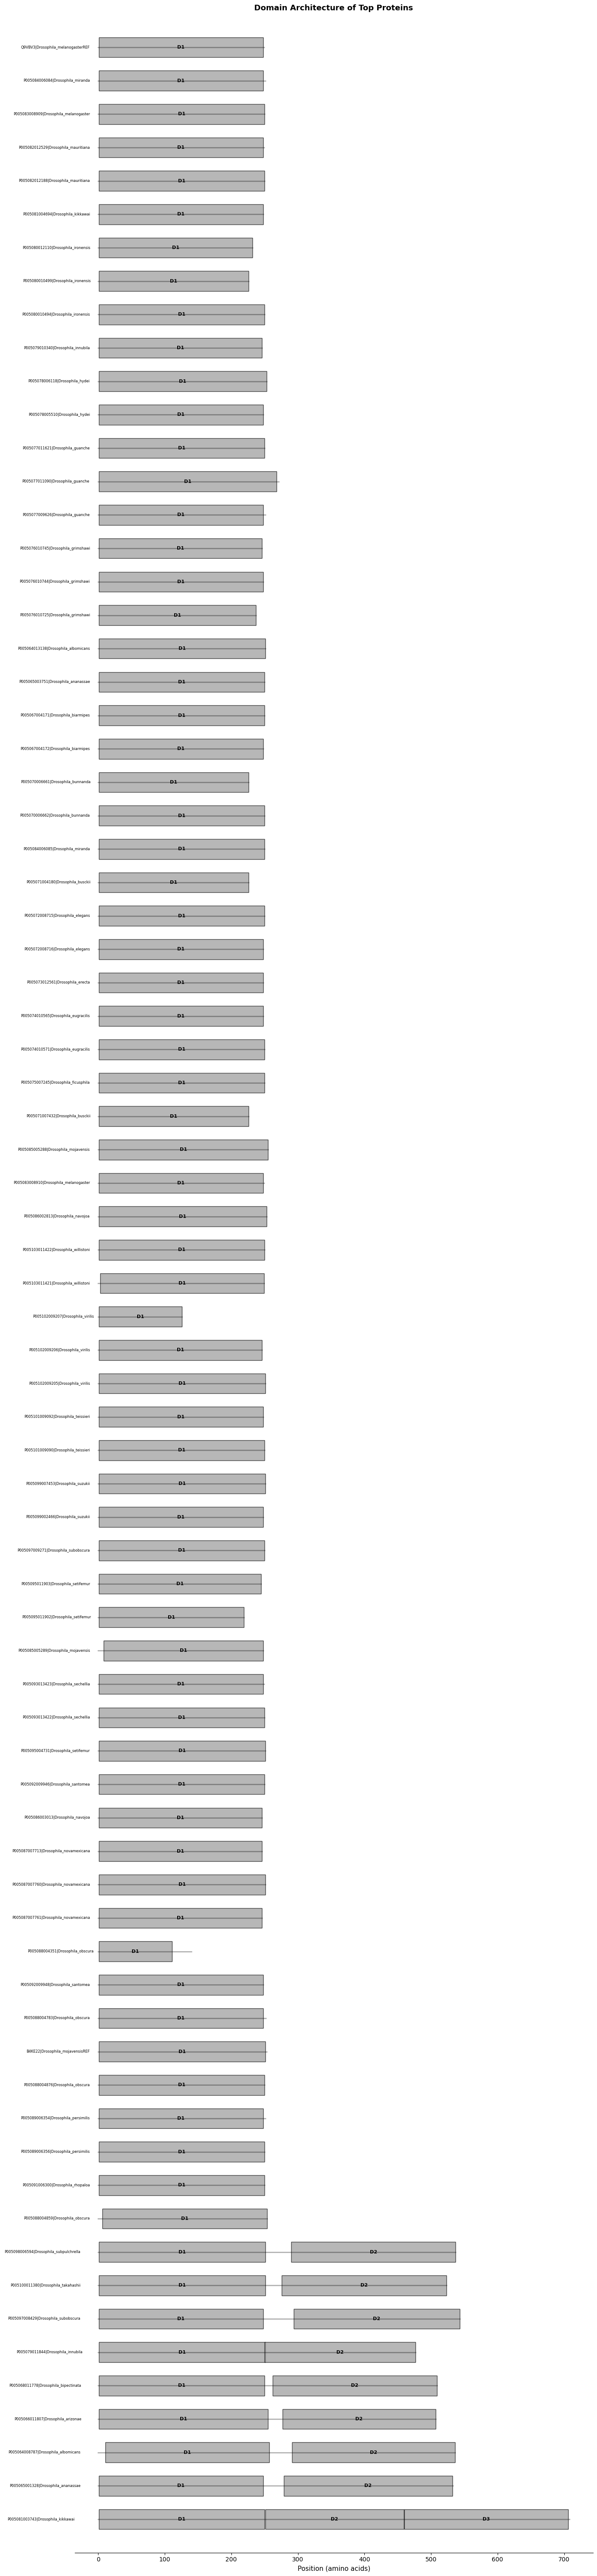

In [55]:
# Visualize domain architecture
visualize_domain_architecture(INPUT_FASTA, domain_df, max_proteins=83)
# Line extent = Total protein length (biological reality)
# Rectangle extent = Individual domain boundaries (domain start/end positions)